# Wafer Defects with a ResNet

In this notebook we will:
- Experiment with normalization strategies for to handle the WaferMap shapes
- Experiment with strategies to combat the class imbalance problem
- Experiment with different hyperparameters for training
- Train CNN models to classify wafer defect patterns
- Evaluate the performance of the trained CNN model
- Build a Hybrid CNN model with engineered features 

This notebook uses the following workflow to train models:
- [Dataset Cleaning](#Dataset-Cleaning): Renaming columns, Dropping unlabeled data
- [Dataset Preparation](#Dataset-Prep): Normalization, Pytorch Dataloaders, Train/Val/Test split
- [Training](#CNN-Training): Various CNN model architectures that we will train on
- [Evaluation](#Evaluation): Evaluate the trained models

**Dataset name**: WM-811K wafer map [Kaggle](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map)

In [1]:
!pip install pandas kagglehub scikit-learn seaborn -q


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import kagglehub
kagglehub.login()

In [3]:
import os
import sys
import time
import numpy as np
import pandas as pd # pandas==2.3.3 works for this dataset. If not downgrade
import seaborn as sns
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

SEED = 42

In [4]:
path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
print(path)

Resuming download from 33554432 bytes (123131851 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/1.archive (33554432/156686283) bytes left.


100%|██████████| 149M/149M [02:55<00:00, 700kB/s]  

Extracting files...


/root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


In [5]:
print("Loading dataset...")
file_path = "/root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1/LSWMD.pkl" # Change this to where the LSWMD.pkl is downloaded
# file_path = "../data/LSWMD_v2.pkl"
df_original = pd.read_pickle(file_path)
print(f"Done. {len(df_original)} rows loaded.")

Loading dataset...
Done. 811457 rows loaded.


## Dataset Cleaning

In this section, we will do the following dataset cleaning steps to get our dataset ready for training
1. Rename "trianTestLabel" to "trainTestLabel"
2. Drop samples with unlabeled failureType
3. Drop samples with unlabeled trainTestLabel

1. Rename "trianTestLabel" to "trainTestLabel"

In [6]:
df_original = df_original.rename(columns={"trianTestLabel":"trainTestLabel"})

2. Drop samples with unlabeled `failureType` and unlabeled `trainTestLabel`

In [7]:
df_original["failureType_str"] = df_original["failureType"].astype(str)
df_original["trainTestLabel_str"] = df_original["trainTestLabel"].astype(str)

In [8]:
df_labeled = df_original[
    (df_original["failureType_str"] != "[]") &
    (df_original["trainTestLabel_str"] != "[]")
].copy()

df_labeled[["failureType", "trainTestLabel"]] = (
    df_labeled[["failureType_str", "trainTestLabel_str"]]
    .apply(lambda s: s.str.replace(r"[\[\]']", "", regex=True).str.strip())
)
df_labeled = df_labeled.reset_index(drop=True)

df_labeled contains 172,950 samples that have a `failureType` label.

In [9]:
print(f"df_labeled: {len(df_labeled):,} samples\n")
print(df_labeled["failureType"].value_counts())

df_labeled: 172,950 samples

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## Dataset Prep

In this section, we will do the following pre-processing steps:

1. Wafer Map Shape Normalization
2. Train/Val/Test split

In [10]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label as cc_label
from sklearn.utils.class_weight import compute_class_weight

In [11]:
classes = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]

### 1. Wafer Map Shape Normalization

We have two different strategies to normalize the wafer map shape

1. Resize all wafer map to IMG_SIZExIMG_SIZE (Naive approach)
2. Resize and pad

Additionally, we will also map the pixels [0,2] of the wafer map to to [0,1]

In [12]:
IMG_SIZE  = 64
CLASSES = ["none", "Edge-Ring", "Edge-Loc", "Center", "Loc", "Scratch", "Random", "Donut", "Near-full"]
LABEL_MAP = {c: i for i, c in enumerate(CLASSES)}
print(LABEL_MAP)

{'none': 0, 'Edge-Ring': 1, 'Edge-Loc': 2, 'Center': 3, 'Loc': 4, 'Scratch': 5, 'Random': 6, 'Donut': 7, 'Near-full': 8}


Resize and pad strategy

- Resize while maintaining aspect ratio.
- Resize longest side to target, pad shorter side with zeros (0 = outside wafer).

In [13]:
def resize_and_pad(wm, target=IMG_SIZE):
    """
    Resize while maintaining aspect ratio.
    Resize longest side to target, pad shorter side with zeros (0 = outside wafer).
    """
    h, w  = wm.shape
    scale = target / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)

    wm_img = Image.fromarray(wm).resize((new_w, new_h), Image.NEAREST)

    pad_h = target - new_h
    pad_w = target - new_w
    wm_padded = np.pad(
        np.array(wm_img),
        ((pad_h // 2, pad_h - pad_h // 2),
         (pad_w // 2, pad_w - pad_w // 2)),
        mode="constant",
        constant_values=0
    )
    return wm_padded

Augmentations

In [14]:
AUGMENTATION = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([
        transforms.Lambda(lambda x: x), # no rotation
        transforms.RandomRotation(degrees=(90, 90), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomRotation(degrees=(180, 180), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomRotation(degrees=(270, 270), interpolation=transforms.InterpolationMode.NEAREST),
    ]),
])

Denoising

In [15]:
class Denoise:
    """
    Remove small isolated clusters of defective dies (noise).
    Note: We skip denoising for Random class
    """
    def __init__(self, min_size=3, p_remove=0.5):
        self.min_size = min_size
        self.p_remove = p_remove

    def __call__(self, x):
        arr = x.squeeze(0).numpy().copy()
        defective = (arr == 1.0)
        labeled, n_clusters = cc_label(defective)
        for cluster_id in range(1, n_clusters + 1):
            cluster_mask = (labeled == cluster_id)
            if cluster_mask.sum() < self.min_size:
                if torch.rand(1).item() < self.p_remove:
                    arr[cluster_mask] = 0.5
        return torch.from_numpy(arr).unsqueeze(0)

DENOISE_FN = Denoise(min_size=3, p_remove=0.5)

Over/Undersampling

In [16]:
def balance_df(df, oversample=False, oversample_target=2000, undersample=False, undersample_target=50000):
    """
    Apply oversampling and/or undersampling to a dataframe based on failureType.
    Args:
        df: dataframe with failureType column
        oversample: if True, upsample minority classes to oversample_target (excludes "none")
        oversample_target: minimum number of samples per class after oversampling
        undersample: if True, downsample "none" class to undersample_target
        undersample_target: max number of "none" samples after undersampling
    """
    if oversample:
        oversampled = []
        for cls in CLASSES:
            cls_df = df[df["failureType"] == cls]
            if cls != "none" and len(cls_df) < oversample_target:
                extra = cls_df.sample(oversample_target - len(cls_df), replace=True, random_state=SEED)
                cls_df = pd.concat([cls_df, extra])
            oversampled.append(cls_df)
        df = pd.concat(oversampled).sample(frac=1, random_state=SEED)

    if undersample and undersample_target is not None:
        none_df  = df[df["failureType"] == "none"].sample(undersample_target, random_state=SEED)
        other_df = df[df["failureType"] != "none"]
        df = pd.concat([none_df, other_df])

    return df.reset_index(drop=True)

Wafer Dataset Class

In [17]:
class WaferDataset(Dataset):
    """
    Wafer dataset for CNN training.
    Returns only the wafer tensor with label.
    """
    def __init__(self, df, strategy="pad", augment=False, denoise=False):
        """
        Args:
            df: dataframe with waferMap column
            strategy: "pad" - preserve aspect ratio, pad remainder with zeros
                      "resize" - stretch to IMG_SIZE x IMG_SIZE
            augment: if True, apply random flips and 90° rotations
        """
        self.df = df.reset_index(drop=True)
        self.strategy = strategy
        self.augment = augment
        self.denoise = denoise

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Map values to [0,1]
        wm  = np.array(row["waferMap"], dtype=np.float32) / 2.0

        # Shape Normalization
        if self.strategy == "pad": # Resize and pad to IMG_SIZE
            wm_array = resize_and_pad(wm)
        else: # resize to IMG_SIZE
            wm_array = np.array(Image.fromarray(wm).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
            
        wm_tensor = torch.from_numpy(wm_array).unsqueeze(0)  # (1, H, W)
        label = LABEL_MAP[row["failureType"]]

        # Augmentations
        if self.augment:
            wm_tensor = AUGMENTATION(wm_tensor)

        # Denoise
        if self.denoise and row["failureType"] != "random":
            wm_tensor = DENOISE_FN(wm_tensor)

        return wm_tensor, label

Visualise a sample before and after each resizing strategy

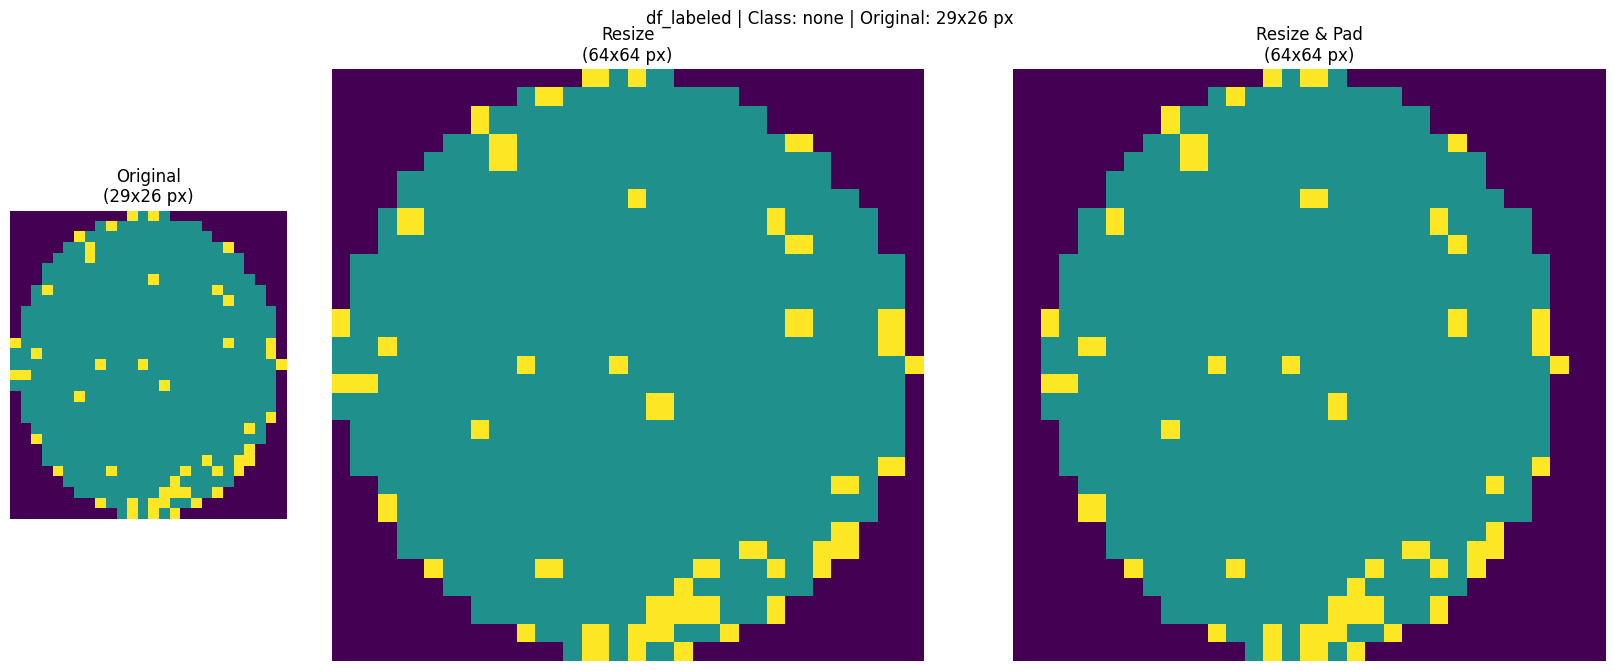

In [18]:
sample_row = df_labeled.sample(1, random_state=np.random.randint(0, 10000)).iloc[0]
wm_raw = np.array(sample_row["waferMap"], dtype=np.float32) / 2.0
wm_resize = np.array(Image.fromarray(wm_raw).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
wm_pad = resize_and_pad(wm_raw)

h, w = wm_raw.shape
scale = 0.1
total_w = w + IMG_SIZE + IMG_SIZE
fig = plt.figure(figsize=(total_w * scale + 1, max(h, IMG_SIZE) * scale + 1))

ax1 = fig.add_axes([0/total_w, 0.1, w/total_w, 0.8])
ax2 = fig.add_axes([w/total_w, 0.1, IMG_SIZE/total_w, 0.8])
ax3 = fig.add_axes([(w+IMG_SIZE)/total_w, 0.1, IMG_SIZE/total_w, 0.8])

ax1.imshow(wm_raw, cmap="viridis", interpolation="nearest")
ax1.set_title(f"Original\n({h}x{w} px)")
ax2.imshow(wm_resize, cmap="viridis", interpolation="nearest")
ax2.set_title(f"Resize\n({IMG_SIZE}x{IMG_SIZE} px)")
ax3.imshow(wm_pad, cmap="viridis", interpolation="nearest")
ax3.set_title(f"Resize & Pad\n({IMG_SIZE}x{IMG_SIZE} px)")

for ax in [ax1, ax2, ax3]:
    ax.axis("off")

plt.suptitle(f"df_labeled | Class: {sample_row['failureType']} | Original: {h}x{w} px", fontsize=12)
plt.show()

### 2. Train/Val/Test Split

There are two different strategies to split the dataset
- Use the split provided by the dataset
- Use a stratified split based on `trainTestLabel`

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
torch.manual_seed(SEED)
np.random.seed(SEED)

BATCH_SIZE = 128
NUM_WORKERS = 8 # number of cores / 2
# NUM_WORKERS = 0

# Choose the normalization strategy
STRATEGY = "pad"  # "resize" or "pad"

# Augmentations
AUGMENTATIONS = True 

# Denoise?
DENOISE = False

# Oversampling
OVERSAMPLE = True
OVERSAMPLE_TARGET = 2000

# Undersampling
UNDERSAMPLE = True
UNDERSAMPLE_TARGET = 50000

VAL_SPLIT  = 0.1 # % of dataset used as validation set
TEST_SPLIT = 0.2 # % of dataset used as test set

In [21]:
# Uncomment to use original dataset train/test split

# df_train = df[df["trainTestLabel"] == "Training"]
# df_test  = df[df["trainTestLabel"] == "Test"]

# # Carve out VAL_SPLIT% of training set as validation, stratified to preserve class distribution
# df_train_final, df_val = train_test_split(
#     df_train,
#     test_size=VAL_SPLIT,
#     random_state=SEED,
#     stratify=df_train["failureType"]
# )


Use a stratified split to create train/val/test using `failureType`

In [22]:
df_train_val, df_test = train_test_split(
    df_labeled,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=df_labeled["failureType"]
)
df_train_final, df_val = train_test_split(
    df_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=df_train_val["failureType"]
)

In [23]:
df_train_balanced = balance_df(
    df_train_final, 
    oversample=OVERSAMPLE, 
    oversample_target=OVERSAMPLE_TARGET, 
    undersample=UNDERSAMPLE, 
    undersample_target=UNDERSAMPLE_TARGET
)

Create pytorch train/val/test dataloaders

In [24]:
train_loader = DataLoader(WaferDataset(
        df_train_balanced,
        strategy=STRATEGY,
        augment=AUGMENTATIONS,
        denoise=DENOISE
    ),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader  = DataLoader(WaferDataset(
        df_val, strategy=STRATEGY
    ), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(WaferDataset(
        df_test, strategy=STRATEGY
    ), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

In [25]:
print(f"Batch size: {BATCH_SIZE}")
print(f"Num workers: {NUM_WORKERS}")
print(f"Strategy: {STRATEGY}\n")
print(f"Augmentations: {AUGMENTATIONS}")
print(f"Oversample: {OVERSAMPLE} | Oversample Target: {OVERSAMPLE_TARGET}")
print(f"Undersample: {UNDERSAMPLE} | Undersample Target: {UNDERSAMPLE_TARGET}\n")
print(f"Train: {len(train_loader.dataset)} | Val: {len(df_val)} | Test: {len(df_test)}")
x, y = next(iter(train_loader))
print(f"Batch shape: {x.shape}")
print(f"Pixel range: {x.min():.2f} - {x.max():.2f}")

print("\n--- Split Counts ---")
print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for cls in classes:
    train_count = (train_loader.dataset.df["failureType"] == cls).sum()
    val_count   = (val_loader.dataset.df["failureType"]   == cls).sum()
    test_count  = (test_loader.dataset.df["failureType"]  == cls).sum()
    print(f"{cls:<12} {train_count:>8} {val_count:>8} {test_count:>8}")
print("-" * 40)
print(f"{'Total':<12} {len(train_loader.dataset):>8} {len(val_loader.dataset):>8} {len(test_loader.dataset):>8}")

Batch size: 128
Num workers: 8
Strategy: pad

Augmentations: True
Oversample: True | Oversample Target: 2000
Undersample: True | Undersample Target: 50000

Train: 73930 | Val: 17295 | Test: 34590
Batch shape: torch.Size([128, 1, 64, 64])
Pixel range: 0.00 - 1.00

--- Split Counts ---
Class           Train      Val     Test
----------------------------------------
none            50000    14743    29486
Edge-Ring        6776      968     1936
Edge-Loc         3632      519     1038
Center           3006      429      859
Loc              2516      359      718
Scratch          2000      119      239
Random           2000       87      173
Donut            2000       56      111
Near-full        2000       15       30
----------------------------------------
Total           73930    17295    34590


## CNN Training

We've established a CNN architecture for this task called CNN_LARGE

The ideal workflow for training is as follows:
1. Create or use an existing [architecture](#Architectures)
2. Create a training loop in [Model Training](#Model-Training)
3. Evaluate the trained mode in the [Evaluation](#Evaluation) section using the helpers

Refer to the [Google Sheet](https://docs.google.com/spreadsheets/d/1EEcb5PDYZJYiHAMukCWQQq_caa4rk-uP/edit?usp=drive_link&ouid=115259893505039818868&rtpof=true&sd=true) for more information on the experiments ran

In [26]:
import torch.nn as nn
import torch.nn.functional as F

In [27]:
# Use GPU if available
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print(f"Device: {device}")

Device: cuda


### Architectures

#### ResNet18

In [28]:
from torchvision.models import resnet18

class ResNet18(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)
    def forward(self, x):
        return self.backbone(x)

resnet = ResNet18(num_classes=9).to(device)
total_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 11,174,857


In [29]:
resnet

ResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

### Model Training


In [30]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, f1_score

results = {}

In [32]:
resnet = ResNet18().to(device)

learning_rate = 1e-4
weight_decay  = 1e-2
eta_min = 1e-6

MAX_EPOCHS = 100
PATIENCE = 20
T_MAX = 50

LABEL_SMOOTHING = 0.1

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(resnet.parameters(), lr=learning_rate, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=eta_min)

In [33]:
train_losses, val_losses, val_accs, val_f1s, lrs = [], [], [], [], []
best_loss = [float("inf"), 0] # [val loss, train loss]
best_f1 = [-1.0, float("inf"), 0]  # [val f1, val loss, train loss]
patience_counter = 0
best_weights = None

start_time = time.time()

for epoch in tqdm(range(MAX_EPOCHS), desc="Epochs"):
    # Train
    resnet.train()
    running_loss = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(resnet(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # Val
    resnet.eval()
    running_loss = 0
    correct = 0
    total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = resnet(x)
            running_loss += criterion(logits, y).item()
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    val_loss = running_loss / len(val_loader)
    val_acc = correct / total
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    lrs.append(optimizer.param_groups[0]["lr"])

    # Uncomment if cosine annealing is turned on
    # scheduler.step()

    if val_loss < best_loss[0]:
        best_loss[0] = val_loss
        best_loss[1] = train_loss
        
    # Early stopping on val F1
    if val_f1 > best_f1[0]:
        best_f1[0] = val_f1
        best_f1[1] = val_loss
        best_f1[2] = train_loss
        patience_counter = 0
        best_weights = {k: v.clone() for k, v in resnet.state_dict().items()}
    else:
        patience_counter += 1

    tqdm.write(
        f"Epoch {epoch+1:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        # f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
        f"Patience: {patience_counter}/{PATIENCE}"
    )

    if patience_counter >= PATIENCE:
        tqdm.write(f"Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time
resnet.load_state_dict(best_weights)
tqdm.write(f"Restored best model — val F1: {best_f1[0]:.4f} | val loss at that epoch: {best_f1[1]:.4f}")

results["resnet"] = {
    "metrics": {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "val_f1s": val_f1s
    },
    "best_val_f1": best_f1[0],
    "best_val_loss_at_f1": best_f1[1],
    "best_train_loss_at_f1": best_f1[2],
    "best_val_loss": best_loss[0],
    "best_train_loss_at_loss": best_loss[1],
    "epochs_trained": len(train_losses),
    "training_time_sec": elapsed,
    "hyperparams": {
        "batch_size": train_loader.batch_size,
        "learning_rate": learning_rate,
        "lrs": lrs,
        "weight_decay": weight_decay,
        "scheduler": "None",
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "label_smoothing": LABEL_SMOOTHING
    },
    "dataset": {
        "strategy": STRATEGY,
        "augmentations": AUGMENTATIONS,
        "oversample": OVERSAMPLE,
        "oversample_target": OVERSAMPLE_TARGET,
        "undersample": UNDERSAMPLE,
        "undersample_target": UNDERSAMPLE_TARGET,
        "n_train": len(train_loader.dataset),
        "n_val": len(val_loader.dataset),
        "n_test": len(test_loader.dataset)
    }
}

print(f"\nTraining Time: {results['resnet']['training_time_sec']/60:.4f} min")

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 01 | Train: 0.7664 | Val: 0.5930 | Val F1: 0.7621 | LR: 1.00e-04 | Patience: 0/20


Epoch 2:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 02 | Train: 0.6566 | Val: 0.5802 | Val F1: 0.7730 | LR: 1.00e-04 | Patience: 0/20


...

Epoch 39 | Train: 0.5170 | Val: 0.5730 | Val F1: 0.8461 | LR: 1.00e-04 | Patience: 18/20


Epoch 40:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 40 | Train: 0.5168 | Val: 0.5572 | Val F1: 0.8496 | LR: 1.00e-04 | Patience: 19/20


Epoch 41:   0%|          | 0/578 [00:00<?, ?it/s]

Epoch 41 | Train: 0.5160 | Val: 0.5585 | Val F1: 0.8530 | LR: 1.00e-04 | Patience: 20/20
Early stopping at epoch 41
Restored best model — val F1: 0.8751 | val loss at that epoch: 0.5461

Training Time: 5.4844 min


## Evaluation

In this section, we evaluate the models we trained in the above section. 

For each model, there are three evaluation metrics displayed
1. Per class metrics
2. Loss curve
3. Confusion matrix

In [34]:
# Uncomment if loading saved weights

# model_path = "checkpoints/best/resnet.pt" # change to where the weights are saved
# resnet = ResNet18().to(device)

# if os.path.exists(model_path):
#     ckpt = torch.load(model_path, map_location=device, weights_only=False)
#     resnet.load_state_dict(ckpt["model_state_dict"])
#     results["resnet"] = ckpt["results"]
#     print(f"Loaded {model_path}")
# else:
#     print(f"No checkpoint at {model_path}")

### Helpers

In [35]:
def evaluate_model(model, loader, run_name):
    model.eval()
    all_preds, all_labels = [], []
    test_running_loss = 0
    criterion_eval = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Evaluating {run_name}"):
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_running_loss += criterion_eval(out, y).item()
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())
    test_loss = round(test_running_loss / len(loader), 4)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    results[run_name].update({
        "test": {
            "accuracy": round(report["accuracy"], 4),
            "macro_f1": round(report["macro avg"]["f1-score"], 4),
            "macro_precision": round(report["macro avg"]["precision"], 4),
            "macro_recall": round(report["macro avg"]["recall"], 4),
            "test_loss": test_loss,
            "preds": all_preds,
            "labels": all_labels,
            **{f"f1_{cls}": round(report[cls]["f1-score"], 4) for cls in classes},
        }
    })

    best_val_loss = results[run_name]["best_val_loss_at_f1"]
    best_train_loss = results[run_name]["best_train_loss_at_f1"]

    print(f"\n--- {run_name} ---")
    print(f"Train Loss: {best_train_loss:.4f} | Val Loss: {best_val_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"\nPer-class Metrics:")
    print(f"{'Class':<12} {'F1':>10} {'Precision':>10} {'Recall':>10}")
    print("-" * 46)
    for cls in classes:
        print(
            f"{cls:<12} "
            f"{report[cls]['f1-score']:>10.4f} "
            f"{report[cls]['precision']:>10.4f} "
            f"{report[cls]['recall']:>10.4f}"
        )
    print("-" * 46)
    print(
        f"{'macro avg':<12} "
        f"{report['macro avg']['f1-score']:>10.4f} "
        f"{report['macro avg']['precision']:>10.4f} "
        f"{report['macro avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    print(f"\nTraining Time: {results[run_name]['training_time_sec']/60:.4f} min")

In [36]:
def plot_losses(run_name):
    train = results[run_name]["metrics"]["train_losses"]
    val = results[run_name]["metrics"]["val_losses"]
    best_val = results[run_name]["best_val_loss"]
    best_val_epoch = val.index(best_val)
    best_train = min(train)
    
    plt.figure(figsize=(6, 4))
    plt.plot(train, label=f"Train (best: {best_train:.4f})")
    plt.plot(val, label=f"Val (best: {best_val:.4f})")
    plt.axhline(best_val, color="red", linestyle="--", linewidth=0.8)
    plt.axvline(best_val_epoch, color="red", linestyle="--", linewidth=0.8)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{run_name} — Loss Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_val_metrics(run_name):
    val_accs = results[run_name]["metrics"]["val_accs"]
    val_f1s = results[run_name]["metrics"]["val_f1s"]
    best_acc = max(val_accs)
    best_acc_epoch = val_accs.index(best_acc)
    best_f1 = max(val_f1s)
    best_f1_epoch = val_f1s.index(best_f1)
    
    plt.figure(figsize=(6, 4))
    plt.plot(val_accs, label=f"Val Acc (best: {best_acc:.4f})", color="C0")
    plt.plot(val_f1s, label=f"Val Macro F1 (best: {best_f1:.4f})", color="C1")
    plt.axhline(best_acc, color="C0", linestyle="--", linewidth=0.8)
    plt.axhline(best_f1, color="C1", linestyle="--", linewidth=0.8)
    plt.axvline(best_f1_epoch, color="C1", linestyle="--", linewidth=0.8)
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{run_name} — Val Accuracy & F1")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_lr(run_name):
    lrs = results[run_name]["hyperparams"]["lrs"]
    plt.figure(figsize=(6, 4))
    plt.plot(lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title(f"{run_name} — Learning Rate Schedule")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

### Results

In [37]:
evaluate_model(resnet, test_loader, "resnet")

Evaluating resnet:   0%|          | 0/271 [00:00<?, ?it/s]


--- resnet ---
Train Loss: 0.5408 | Val Loss: 0.5461 | Test Loss: 0.5456

Per-class Metrics:
Class                F1  Precision     Recall
----------------------------------------------
none             0.9896     0.9861     0.9931
Edge-Ring        0.9734     0.9741     0.9726
Edge-Loc         0.8147     0.8558     0.7775
Center           0.9344     0.9317     0.9371
Loc              0.7365     0.7961     0.6852
Scratch          0.6572     0.7554     0.5816
Random           0.8914     0.8602     0.9249
Donut            0.8245     0.7537     0.9099
Near-full        0.9355     0.9062     0.9667
----------------------------------------------
macro avg        0.8619     0.8688     0.8610

Overall Accuracy: 0.9742

Training Time: 5.4844 min


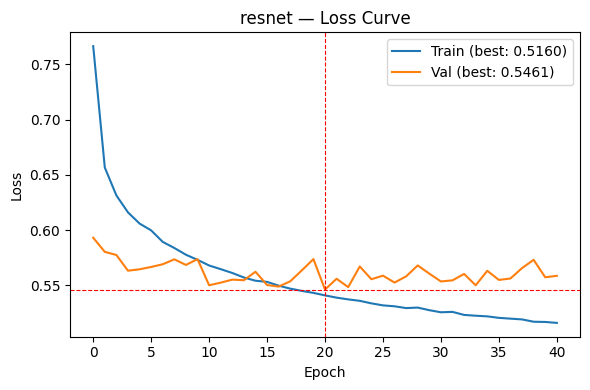

In [38]:
plot_losses("resnet")

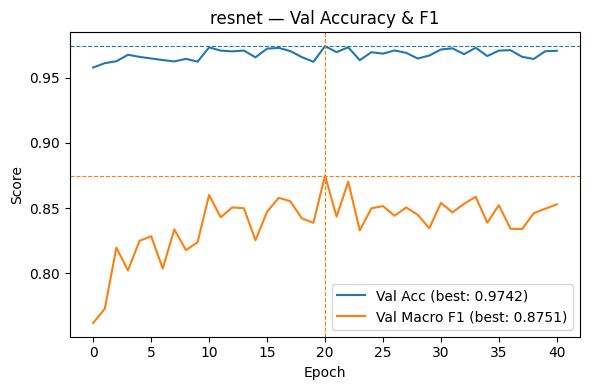

In [39]:
plot_val_metrics("resnet")

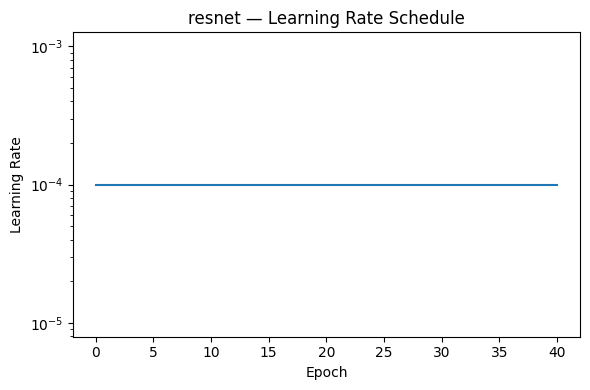

In [40]:
plot_lr("resnet")

Save model

In [41]:
def save_checkpoint(model, results, file_name):
    save_dir = Path("checkpoints")
    save_dir.mkdir(parents=True, exist_ok=True)

    save_path = save_dir / f"{file_name}.pt"

    torch.save({
        "model_state_dict": model.state_dict(),
        "results": results
    }, save_path)

    print(f"Checkpoint saved to: {save_path}")

In [42]:
save_checkpoint(resnet, results["resnet"], "resnet")

Checkpoint saved to: checkpoints/resnet.pt


Test Time Augmentations

In [43]:
from scipy.optimize import minimize

def get_probs(model, loader):
    """Return (probs, labels) as numpy arrays."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def tune_thresholds(model, val_loader, test_loader, run_name):
    """Tune per-class thresholds on val probs, evaluate on test."""
    val_probs, val_labels = get_probs(model, val_loader)
    test_probs, test_labels = get_probs(model, test_loader)
    
    def neg_macro_f1(thresholds, probs, labels):
        preds = (probs / thresholds).argmax(axis=1)
        return -f1_score(labels, preds, average="macro", zero_division=0)
    
    result = minimize(
        neg_macro_f1,
        x0=np.ones(len(classes)),
        args=(val_probs, val_labels),
        method="Nelder-Mead",
        options={"xatol": 1e-4, "fatol": 1e-4, "maxiter": 2000}
    )
    best_thresholds = result.x
    val_f1_tuned = -result.fun
    val_f1_baseline = f1_score(val_labels, val_probs.argmax(axis=1),
                                average="macro", zero_division=0)
    
    test_preds_tuned = (test_probs / best_thresholds).argmax(axis=1)
    test_preds_baseline = test_probs.argmax(axis=1)
    
    report_tuned = classification_report(
        test_labels, test_preds_tuned,
        target_names=classes, output_dict=True, zero_division=0
    )
    report_baseline = classification_report(
        test_labels, test_preds_baseline,
        target_names=classes, output_dict=True, zero_division=0
    )
    
    results[run_name].update({
        "test_tuned": {
            "accuracy": round(report_tuned["accuracy"], 4),
            "macro_f1": round(report_tuned["macro avg"]["f1-score"], 4),
            "macro_precision": round(report_tuned["macro avg"]["precision"], 4),
            "macro_recall": round(report_tuned["macro avg"]["recall"], 4),
            "preds": test_preds_tuned,
            "labels": test_labels,
            "probs": test_probs,
            "thresholds": best_thresholds,
            "val_f1_baseline": round(val_f1_baseline, 4),
            "val_f1_tuned": round(val_f1_tuned, 4),
            **{f"f1_{cls}": round(report_tuned[cls]["f1-score"], 4) for cls in classes},
        }
    })
    
    print(f"\n--- {run_name} (threshold-tuned) ---")
    print(f"Val F1:  baseline {val_f1_baseline:.4f}  ->  tuned {val_f1_tuned:.4f}  (Change: {val_f1_tuned - val_f1_baseline:+.4f})")
    print(f"\nTuned Thresholds:")
    for cls, t in zip(classes, best_thresholds):
        print(f"  {cls:<12} {t:.4f}")
    
    print(f"\nPer-class Metrics (test):")
    print(f"{'Class':<12} {'F1 base':>10} {'F1 tuned':>10} {'Change':>8} {'Prec':>10} {'Recall':>10}")
    print("-" * 62)
    for cls in classes:
        f1_b = report_baseline[cls]["f1-score"]
        f1_t = report_tuned[cls]["f1-score"]
        print(
            f"{cls:<12} "
            f"{f1_b:>10.4f} "
            f"{f1_t:>10.4f} "
            f"{f1_t - f1_b:>+8.4f} "
            f"{report_tuned[cls]['precision']:>10.4f} "
            f"{report_tuned[cls]['recall']:>10.4f}"
        )
    print("-" * 62)
    print(
        f"{'macro avg':<12} "
        f"{report_baseline['macro avg']['f1-score']:>10.4f} "
        f"{report_tuned['macro avg']['f1-score']:>10.4f} "
        f"{report_tuned['macro avg']['f1-score'] - report_baseline['macro avg']['f1-score']:>+8.4f} "
        f"{report_tuned['macro avg']['precision']:>10.4f} "
        f"{report_tuned['macro avg']['recall']:>10.4f}"
    )
    print(f"\nOverall Accuracy: {report_tuned['accuracy']:.4f}")

In [44]:
tune_thresholds(resnet, val_loader, test_loader, "resnet")


--- resnet (threshold-tuned) ---
Val F1:  baseline 0.8751  ->  tuned 0.8774  (Change: +0.0024)

Tuned Thresholds:
  none         0.8883
  Edge-Ring    1.0320
  Edge-Loc     0.9849
  Center       1.0339
  Loc          0.9825
  Scratch      1.0158
  Random       1.0150
  Donut        1.0555
  Near-full    0.9942

Per-class Metrics (test):
Class           F1 base   F1 tuned   Change       Prec     Recall
--------------------------------------------------------------
none             0.9896     0.9896  +0.0000     0.9855     0.9937
Edge-Ring        0.9734     0.9739  +0.0005     0.9756     0.9721
Edge-Loc         0.8147     0.8146  -0.0002     0.8590     0.7746
Center           0.9344     0.9347  +0.0002     0.9368     0.9325
Loc              0.7365     0.7334  -0.0031     0.7984     0.6783
Scratch          0.6572     0.6539  -0.0033     0.7611     0.5732
Random           0.8914     0.8908  -0.0006     0.8641     0.9191
Donut            0.8245     0.8313  +0.0068     0.7652     0.9099
Nea

### Embeddings

Get embeddings of the samples from the test set

In [255]:
def get_embeddings(model, x):
    x = model.features(x)
    x = x.flatten(1)
    x = torch.relu(model.fc(x))
    return x

all_embeddings = []
all_labels = []
resnet.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        emb = get_embeddings(resnet, x)
        all_embeddings.append(emb.cpu())
        all_labels.append(y)

embeddings = torch.cat(all_embeddings, dim=0).numpy()
labels = torch.cat(all_labels, dim=0).numpy()
print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Embeddings shape: (34590, 256)
Labels shape: (34590,)


TSNE

In [256]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
    verbose=1
)
embeddings_tsne = tsne.fit_transform(embeddings)
print("t-SNE shape:", embeddings_tsne.shape)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 34590 samples in 0.003s...
[t-SNE] Computed neighbors for 34590 samples in 1.653s...
[t-SNE] Computed conditional probabilities for sample 1000 / 34590
[t-SNE] Computed conditional probabilities for sample 2000 / 34590
[t-SNE] Computed conditional probabilities for sample 3000 / 34590
[t-SNE] Computed conditional probabilities for sample 4000 / 34590
[t-SNE] Computed conditional probabilities for sample 5000 / 34590
[t-SNE] Computed conditional probabilities for sample 6000 / 34590
[t-SNE] Computed conditional probabilities for sample 7000 / 34590
[t-SNE] Computed conditional probabilities for sample 8000 / 34590
[t-SNE] Computed conditional probabilities for sample 9000 / 34590
[t-SNE] Computed conditional probabilities for sample 10000 / 34590
[t-SNE] Computed conditional probabilities for sample 11000 / 34590
[t-SNE] Computed conditional probabilities for sample 12000 / 34590
[t-SNE] Computed conditional probabilities for sam

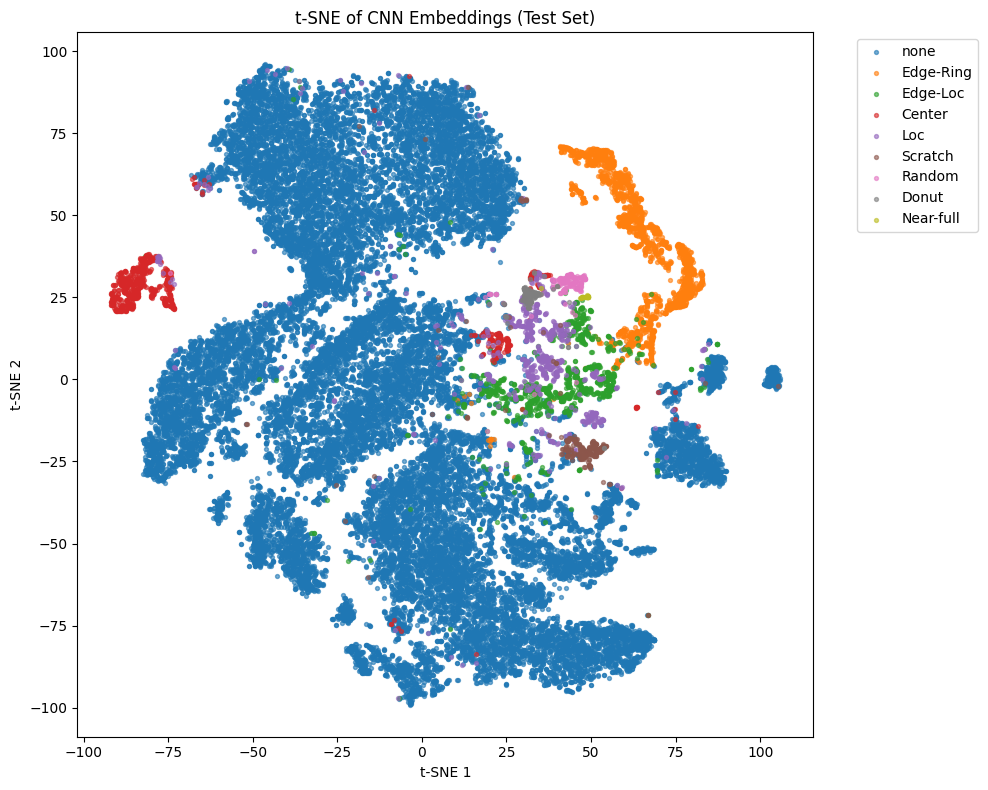

In [257]:
plt.figure(figsize=(10, 8))
unique_labels = np.unique(labels)
for label_idx in unique_labels:
    mask = labels == label_idx
    plt.scatter(
        embeddings_tsne[mask, 0],
        embeddings_tsne[mask, 1],
        s=8,
        alpha=0.6,
        label=classes[label_idx]
    )
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of CNN Embeddings (Test Set)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Visualizations

In [258]:
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

In [259]:
def plot_confusion(run_name, mode="count"):
    preds = results[run_name]["test"]["preds"]
    labels = results[run_name]["test"]["labels"]
    
    cm = confusion_matrix(labels, preds, labels=range(len(classes)))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)
    
    display = cm_norm if mode == "prob" else cm
    
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            value = display[i, j]
            text = f"{value:.2f}" if mode == "prob" else f"{int(value)}"
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Proportion")
    
    plt.title(f"Confusion Matrix")
    plt.tight_layout()
    plt.show()

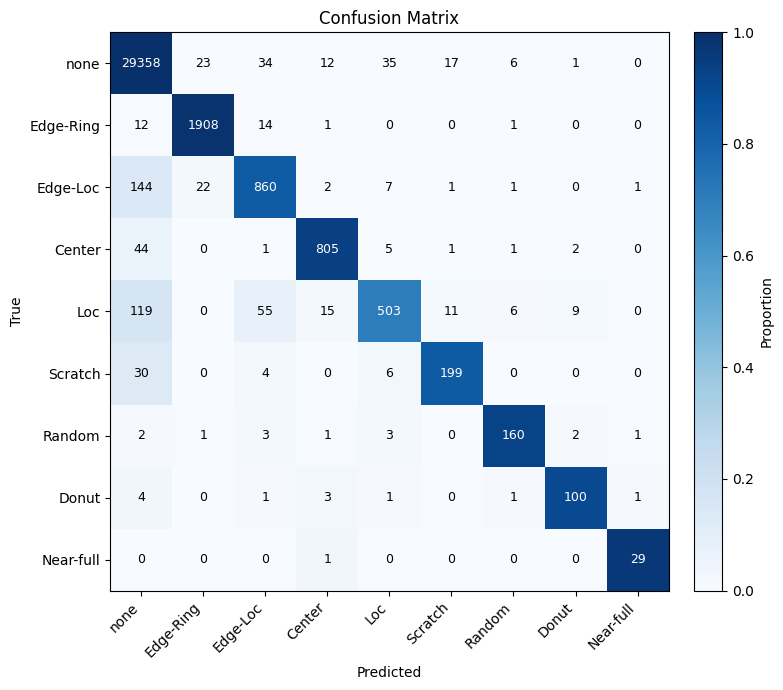

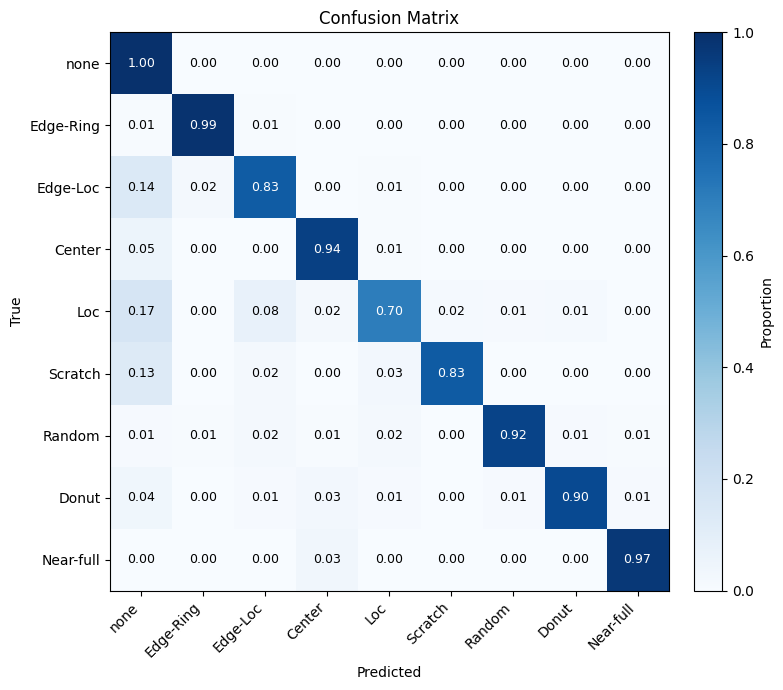

In [260]:
plot_confusion("resnet", mode="count")
plot_confusion("resnet", mode="prob")

In [261]:
def plot_highest_loss_samples(model, loader, run_name, n=5):
    """Shows n highest-loss samples per class."""
    model.eval()
    sample_losses, sample_images, sample_preds, sample_labels = [], [], [], []
    criterion_unreduced = nn.CrossEntropyLoss(reduction="none")
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Computing losses {run_name}"):
            x, y = x.to(device), y.to(device)
            out = model(x)
            losses = criterion_unreduced(out, y)
            preds = out.argmax(dim=1)
            sample_losses.extend(losses.cpu().numpy())
            sample_images.extend(x.cpu().numpy())
            sample_preds.extend(preds.cpu().numpy())
            sample_labels.extend(y.cpu().numpy())
    sample_losses = np.array(sample_losses)
    sample_labels = np.array(sample_labels)
    num_classes = len(classes)
    
    fig, axes = plt.subplots(num_classes, n, figsize=(n * 2, num_classes * 2.5))
    
    for cls_idx, cls_name in enumerate(classes):
        cls_indices = np.where(sample_labels == cls_idx)[0]
        
        if len(cls_indices) == 0:
            for j in range(n):
                axes[cls_idx, j].axis("off")
            axes[cls_idx, 0].set_ylabel(cls_name, fontsize=10, rotation=0, ha="right", va="center")
            continue
        
        cls_losses = sample_losses[cls_indices]
        top_local = np.argsort(cls_losses)[::-1][:n]
        top_global = cls_indices[top_local]
        
        for j in range(n):
            ax = axes[cls_idx, j]
            if j < len(top_global):
                idx = top_global[j]
                img = sample_images[idx][0]
                pred = classes[sample_preds[idx]]
                loss = sample_losses[idx]
                ax.imshow(img, cmap="viridis", interpolation="nearest")
                ax.set_title(f"Pred: {pred}\nLoss: {loss:.2f}", fontsize=8)
            else:
                ax.axis("off")
            ax.set_xticks([])
            ax.set_yticks([])
        
        axes[cls_idx, 0].set_ylabel(cls_name, fontsize=10, rotation=0, ha="right", va="center")
    
    plt.suptitle(f"{run_name} — Top {n} Highest Loss Samples per Class", fontsize=12)
    plt.tight_layout()
    plt.show()

Computing losses cnn_large:   0%|          | 0/271 [00:00<?, ?it/s]

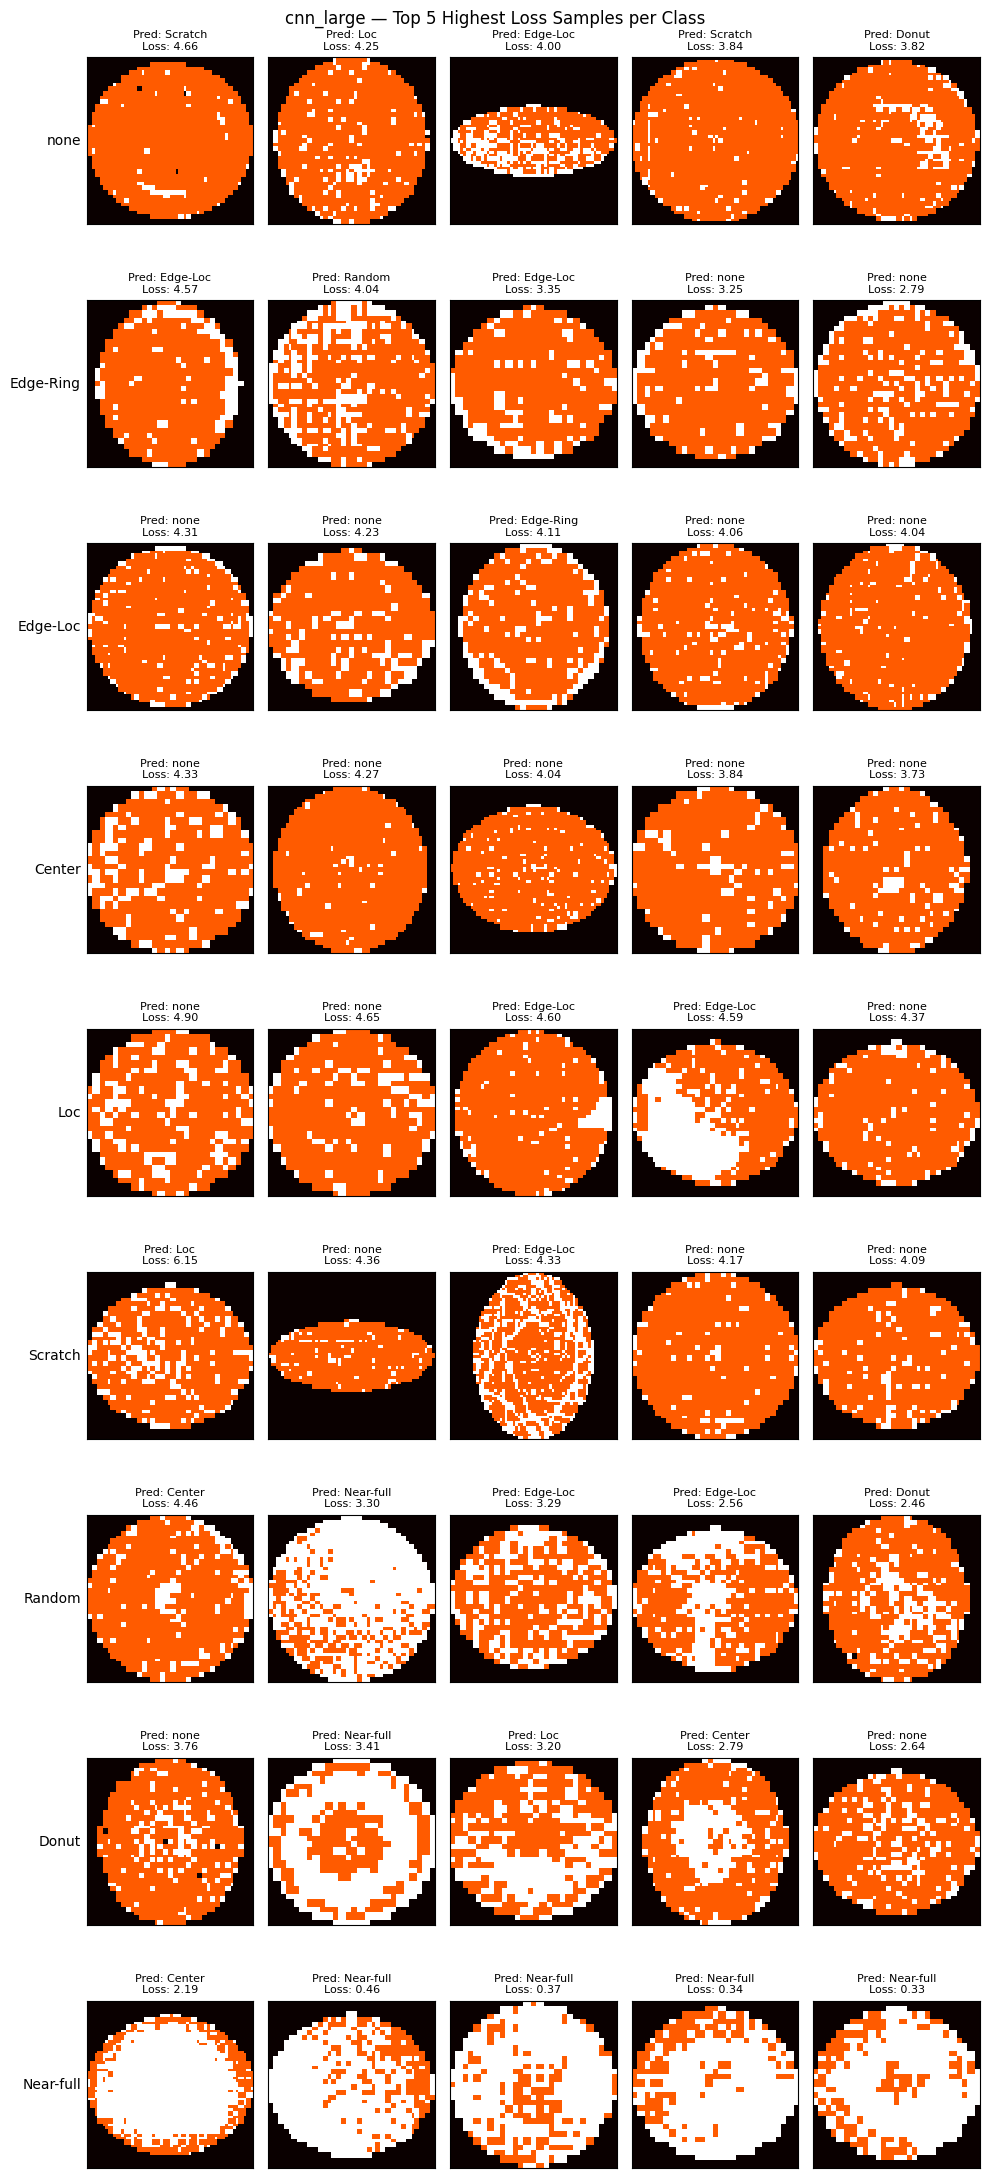

In [262]:
plot_highest_loss_samples(resnet, test_loader, "resnet")

In [263]:
def plot_f1_heatmap_by_size(y_true, y_pred, dims, classes, step=10, max_side=None, resize_target=IMG_SIZE):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    areas = np.array([h * w for h, w in dims])
    
    if max_side is None:
        max_side = int(np.ceil(np.sqrt(areas.max()) / step) * step)
    
    side_edges = np.arange(0, max_side + step, step)
    edges = side_edges ** 2
    edges[-1] = areas.max() + 1
    n_buckets = len(edges) - 1
    
    bucket_idx = np.clip(np.digitize(areas, edges) - 1, 0, n_buckets - 1)
    
    target_area = resize_target * resize_target
    target_bucket = int(np.clip(np.digitize(target_area, edges) - 1, 0, n_buckets - 1))
    
    bucket_labels = []
    for i in range(n_buckets):
        n = int((bucket_idx == i).sum())
        marker = "  ←" if i == target_bucket else ""
        lo, hi = side_edges[i], side_edges[i+1]
        bucket_labels.append(f"{lo}×{lo}–{hi}×{hi}  (n={n}){marker}")
    
    grid = np.full((n_buckets, len(classes)), np.nan)
    counts = np.zeros((n_buckets, len(classes)), dtype=int)
    for b in range(n_buckets):
        mask = bucket_idx == b
        if mask.sum() == 0:
            continue
        f1s = f1_score(y_true[mask], y_pred[mask],
                       labels=range(len(classes)), average=None, zero_division=0)
        for c in range(len(classes)):
            n_c = int((y_true[mask] == c).sum())
            counts[b, c] = n_c
            if n_c == 0:
                continue
            grid[b, c] = f1s[c]
    
    annot = np.where(np.isnan(grid), "",
                     np.array([[f"{grid[i, j]:.2f}\nn={counts[i, j]}" if not np.isnan(grid[i, j]) else ""
                                for j in range(len(classes))] for i in range(n_buckets)]))
    
    fig, ax = plt.subplots(figsize=(11, 0.45 * n_buckets + 2))
    sns.heatmap(
        grid,
        annot=annot,
        fmt="",
        cmap="RdYlGn",
        vmin=0, vmax=1,
        cbar_kws={"label": "F1"},
        linewidths=0.5,
        linecolor="white",
        xticklabels=classes,
        yticklabels=bucket_labels,
        annot_kws={"fontsize": 8},
        ax=ax,
    )
    ax.set_facecolor("#eeeeee")
    ax.set_xlabel("Class")
    ax.set_ylabel(f"Wafer size bucket  (resize target: {resize_target}×{resize_target})")
    ax.set_title(f"Per-class F1 by wafer size bucket (step={step})")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

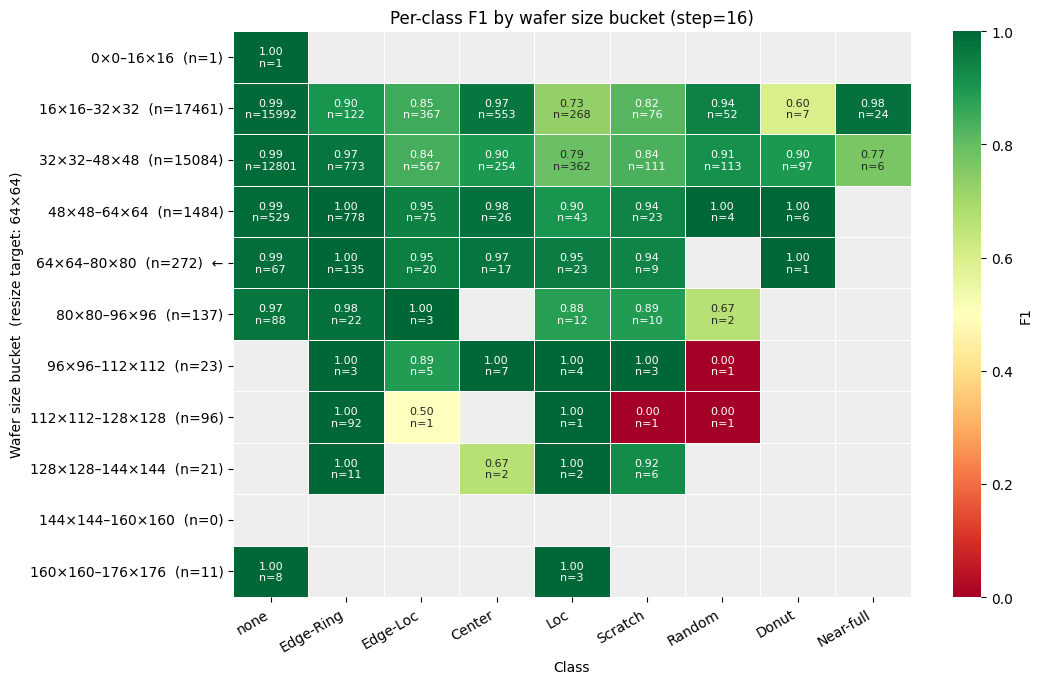

In [264]:
y_true = results["resnet"]["test"]["labels"]
y_pred = results["resnet"]["test"]["preds"]

dims_test = np.array([wm.shape for wm in df_test["waferMap"].values])
plot_f1_heatmap_by_size(y_true, y_pred, dims_test, classes, step=16)

In [265]:
def plot_f1_vs_train_count(y_true, y_pred, df_train, classes, label_map):
    """
    Per-class F1 alongside training sample count.
    
    Args:
        y_true, y_pred: test predictions
        df_train: training dataframe (use df_train_balanced if oversampled)
        classes: list of class names in label index order
        label_map: dict mapping class name -> label index
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    per_class_f1 = f1_score(y_true, y_pred, average=None, labels=range(len(classes)), zero_division=0)
    train_counts = df_train["failureType"].map(label_map).value_counts().sort_index()
    train_counts = [train_counts.get(i, 0) for i in range(len(classes))]
    
    order = np.argsort(train_counts)
    sorted_classes = [classes[i] for i in order]
    sorted_f1 = [per_class_f1[i] for i in order]
    sorted_counts = [train_counts[i] for i in order]
    
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()
    
    x = np.arange(len(sorted_classes))
    ax1.bar(x, sorted_counts, alpha=0.35, color="gray", label="train count")
    ax2.plot(x, sorted_f1, "o-", color="C0", linewidth=2, markersize=8, label="F1")
    
    for i, f1 in enumerate(sorted_f1):
        ax2.annotate(f"{f1:.2f}", (i, f1), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(sorted_classes, rotation=30, ha="right")
    ax1.set_ylabel("Training sample count")
    ax1.set_yscale("log")
    ax2.set_ylabel("F1 score")
    ax2.set_ylim(0, 1.05)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    
    plt.title("Per-class F1 vs. training sample count")
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame({
        "class": sorted_classes,
        "train_count": sorted_counts,
        "f1": sorted_f1,
    })


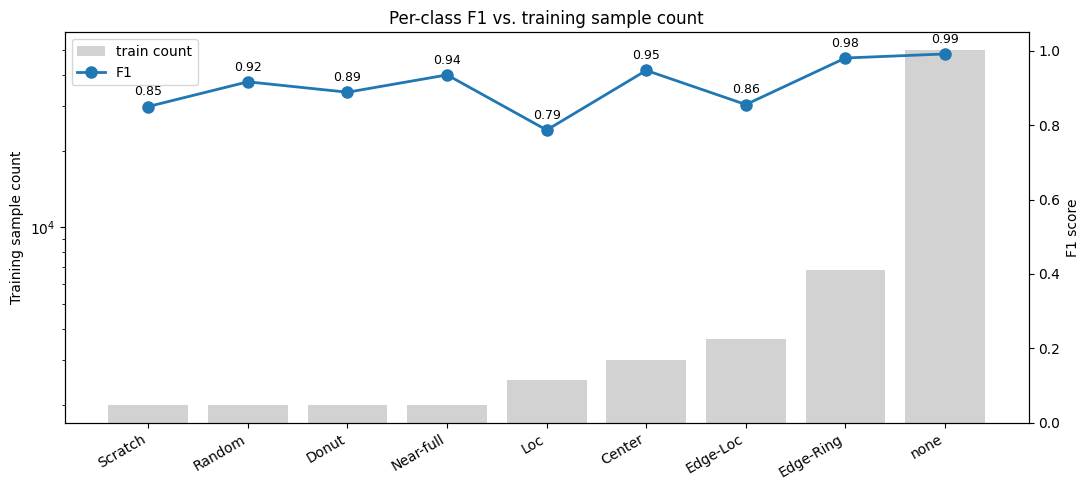

       class  train_count        f1
0    Scratch         2000  0.850427
1     Random         2000  0.916905
2      Donut         2000  0.888889
3  Near-full         2000  0.935484
4        Loc         2516  0.787167
5     Center         3006  0.947616
6   Edge-Loc         3632  0.855721
7  Edge-Ring         6776  0.980977
8       none        50000  0.991841


In [266]:
df_f1 = plot_f1_vs_train_count(y_true, y_pred, df_train_balanced, classes, LABEL_MAP)
print(df_f1)

In [267]:
def get_sample_from_class(df_test, class_name, seed=None):
    """Pick one random sample index from df_test matching class_name."""
    matches = df_test[df_test["failureType"] == class_name]
    if len(matches) == 0:
        raise ValueError(f"No samples of class '{class_name}' in df_test")
    rng = np.random.default_rng(seed)
    return matches.iloc[rng.integers(len(matches))]


def extract_feature_maps(model, x):
    """
    Run x through model.features and return {block_name: activation} after each MaxPool.
    Also returns the input as 'input' for reference.
    """
    model.eval()
    maps = {"input": x.detach().cpu()}
    block_idx = 0
    out = x
    with torch.no_grad():
        for layer in model.features:
            out = layer(out)
            if isinstance(layer, nn.MaxPool2d):
                block_idx += 1
                maps[f"block{block_idx}"] = out.detach().cpu()
    return maps


def plot_feature_maps(maps, block_name, max_channels=32, sort_by_activation=True):
    if block_name not in maps:
        raise ValueError(f"Unknown block '{block_name}'. Available: {list(maps.keys())}")
    
    fmap = maps[block_name][0]  # (C, H, W)
    
    if sort_by_activation and fmap.shape[0] > 1:
        magnitudes = fmap.abs().mean(dim=(1, 2))
        order = torch.argsort(magnitudes, descending=True)
        fmap = fmap[order]
        channel_ids = order.tolist()
    else:
        channel_ids = list(range(fmap.shape[0]))
    
    n_channels = min(fmap.shape[0], max_channels)
    cols = 8 if n_channels > 1 else 1
    rows = int(np.ceil(n_channels / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 2.2))
    axes = np.array(axes).reshape(-1)
    
    for i in range(n_channels):
        axes[i].imshow(fmap[i].numpy(), cmap="viridis")
        axes[i].set_title(f"ch {channel_ids[i]}", fontsize=8)
        axes[i].axis("off")
    for i in range(n_channels, len(axes)):
        axes[i].axis("off")
    
    shape_str = f"{fmap.shape[0]}x{fmap.shape[1]}x{fmap.shape[2]}"
    plt.suptitle(f"{block_name} — {shape_str} (top {n_channels} by activation)", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

In [268]:
# pick a sample
class_name = "Edge-Ring"
row = get_sample_from_class(df_test, class_name, seed=42)

# build the input tensor
idx = df_test.index.get_loc(row.name)
x, y = WaferDataset(df_test, strategy=STRATEGY)[idx]
x = x.unsqueeze(0).to(device)

# extract
maps = extract_feature_maps(resnet, x)
print({k: tuple(v.shape) for k, v in maps.items()})

{'input': (1, 1, 64, 64), 'block1': (1, 32, 32, 32), 'block2': (1, 64, 16, 16), 'block3': (1, 128, 8, 8)}


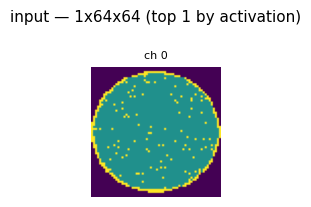

In [269]:
plot_feature_maps(maps, "input")

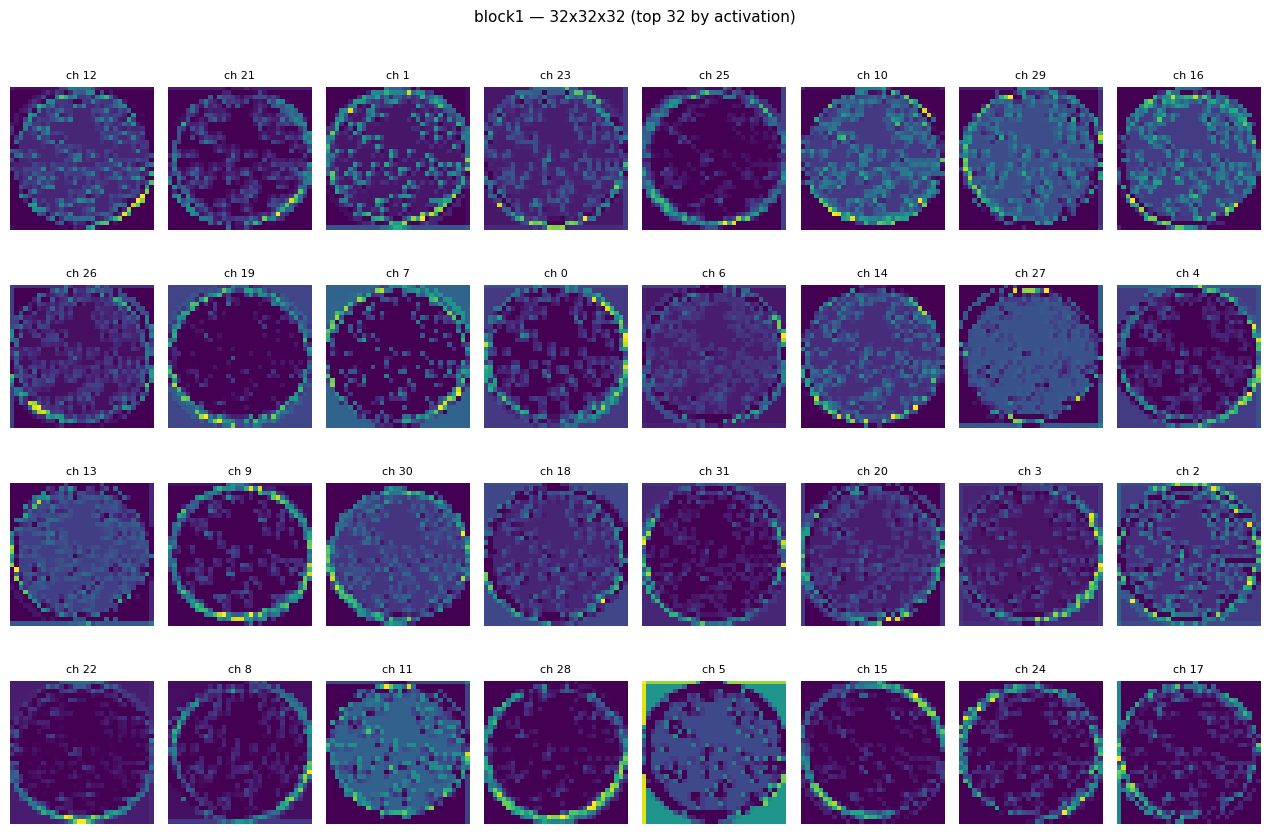

In [270]:
plot_feature_maps(maps, "block1", max_channels=32)

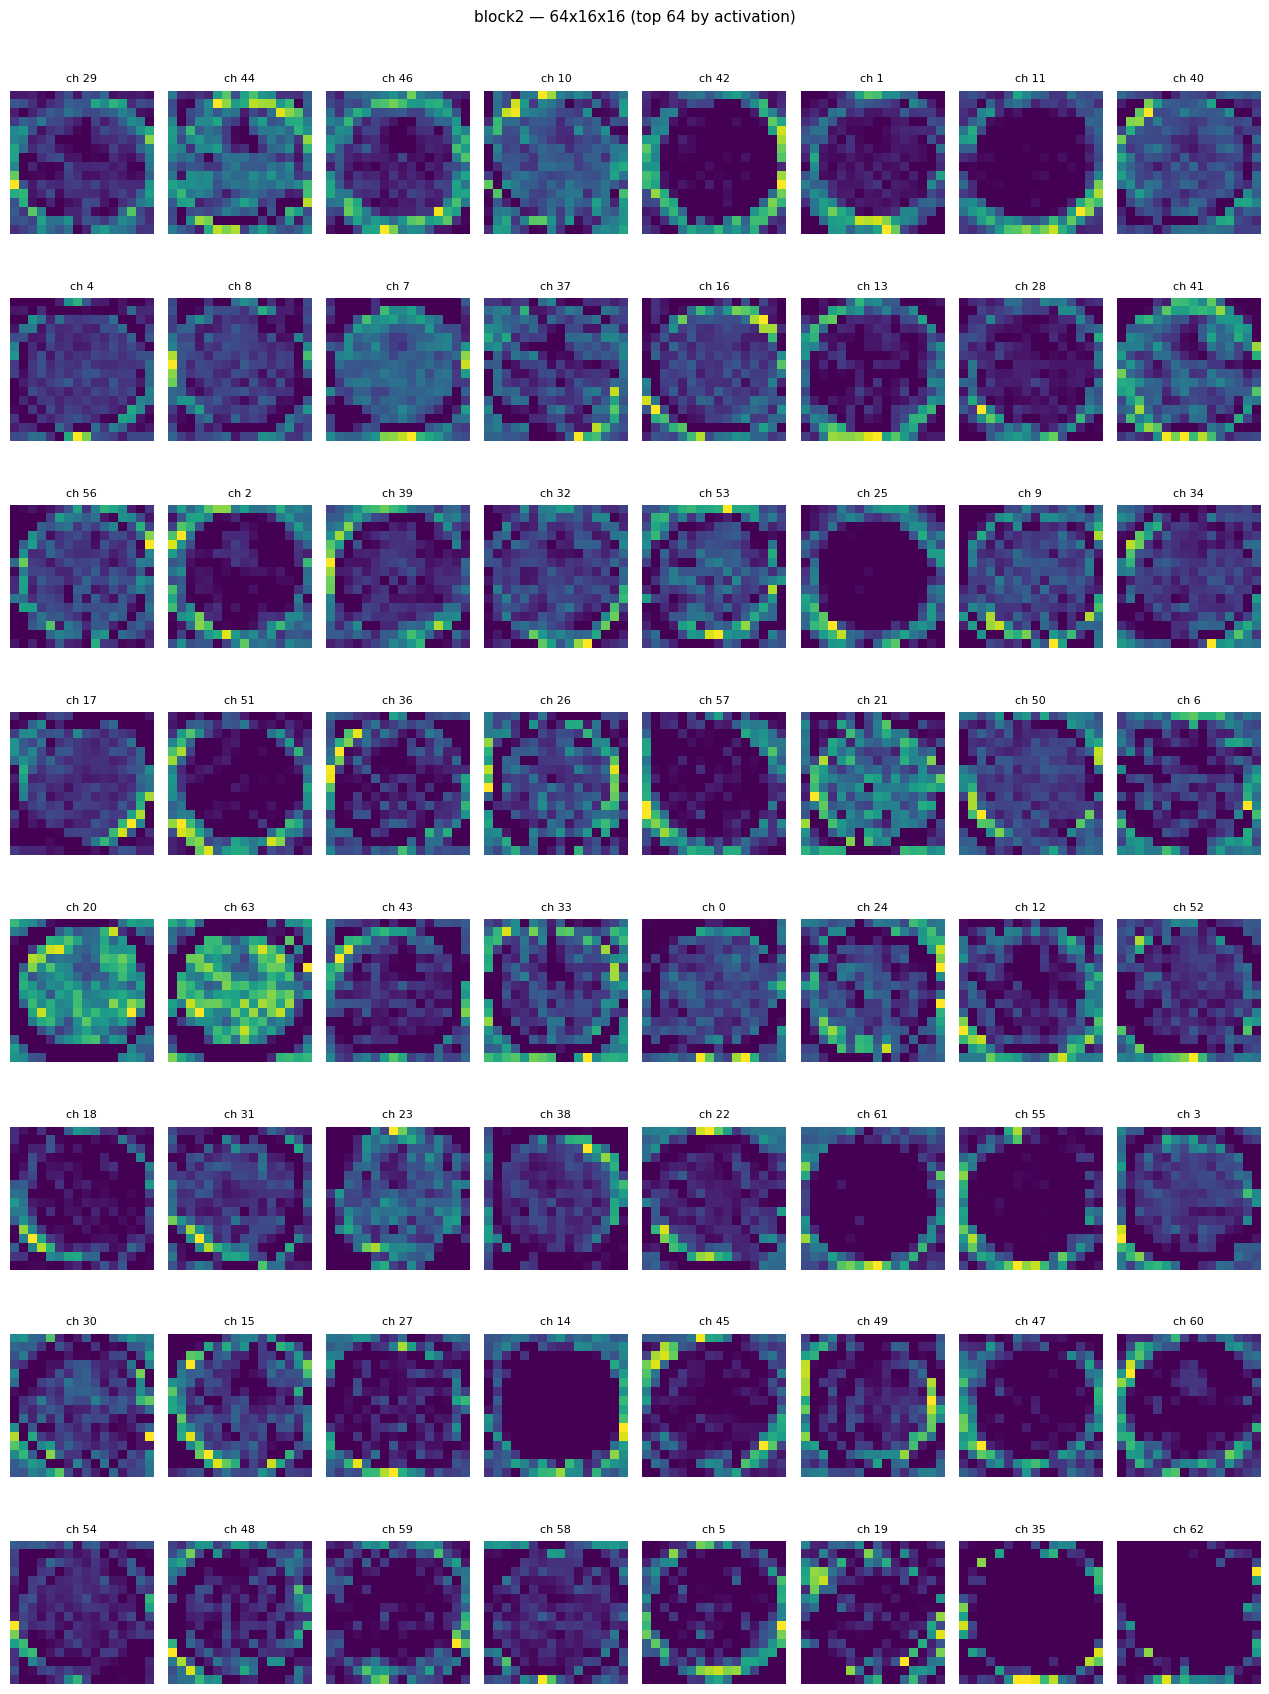

In [271]:
plot_feature_maps(maps, "block2", max_channels=64)

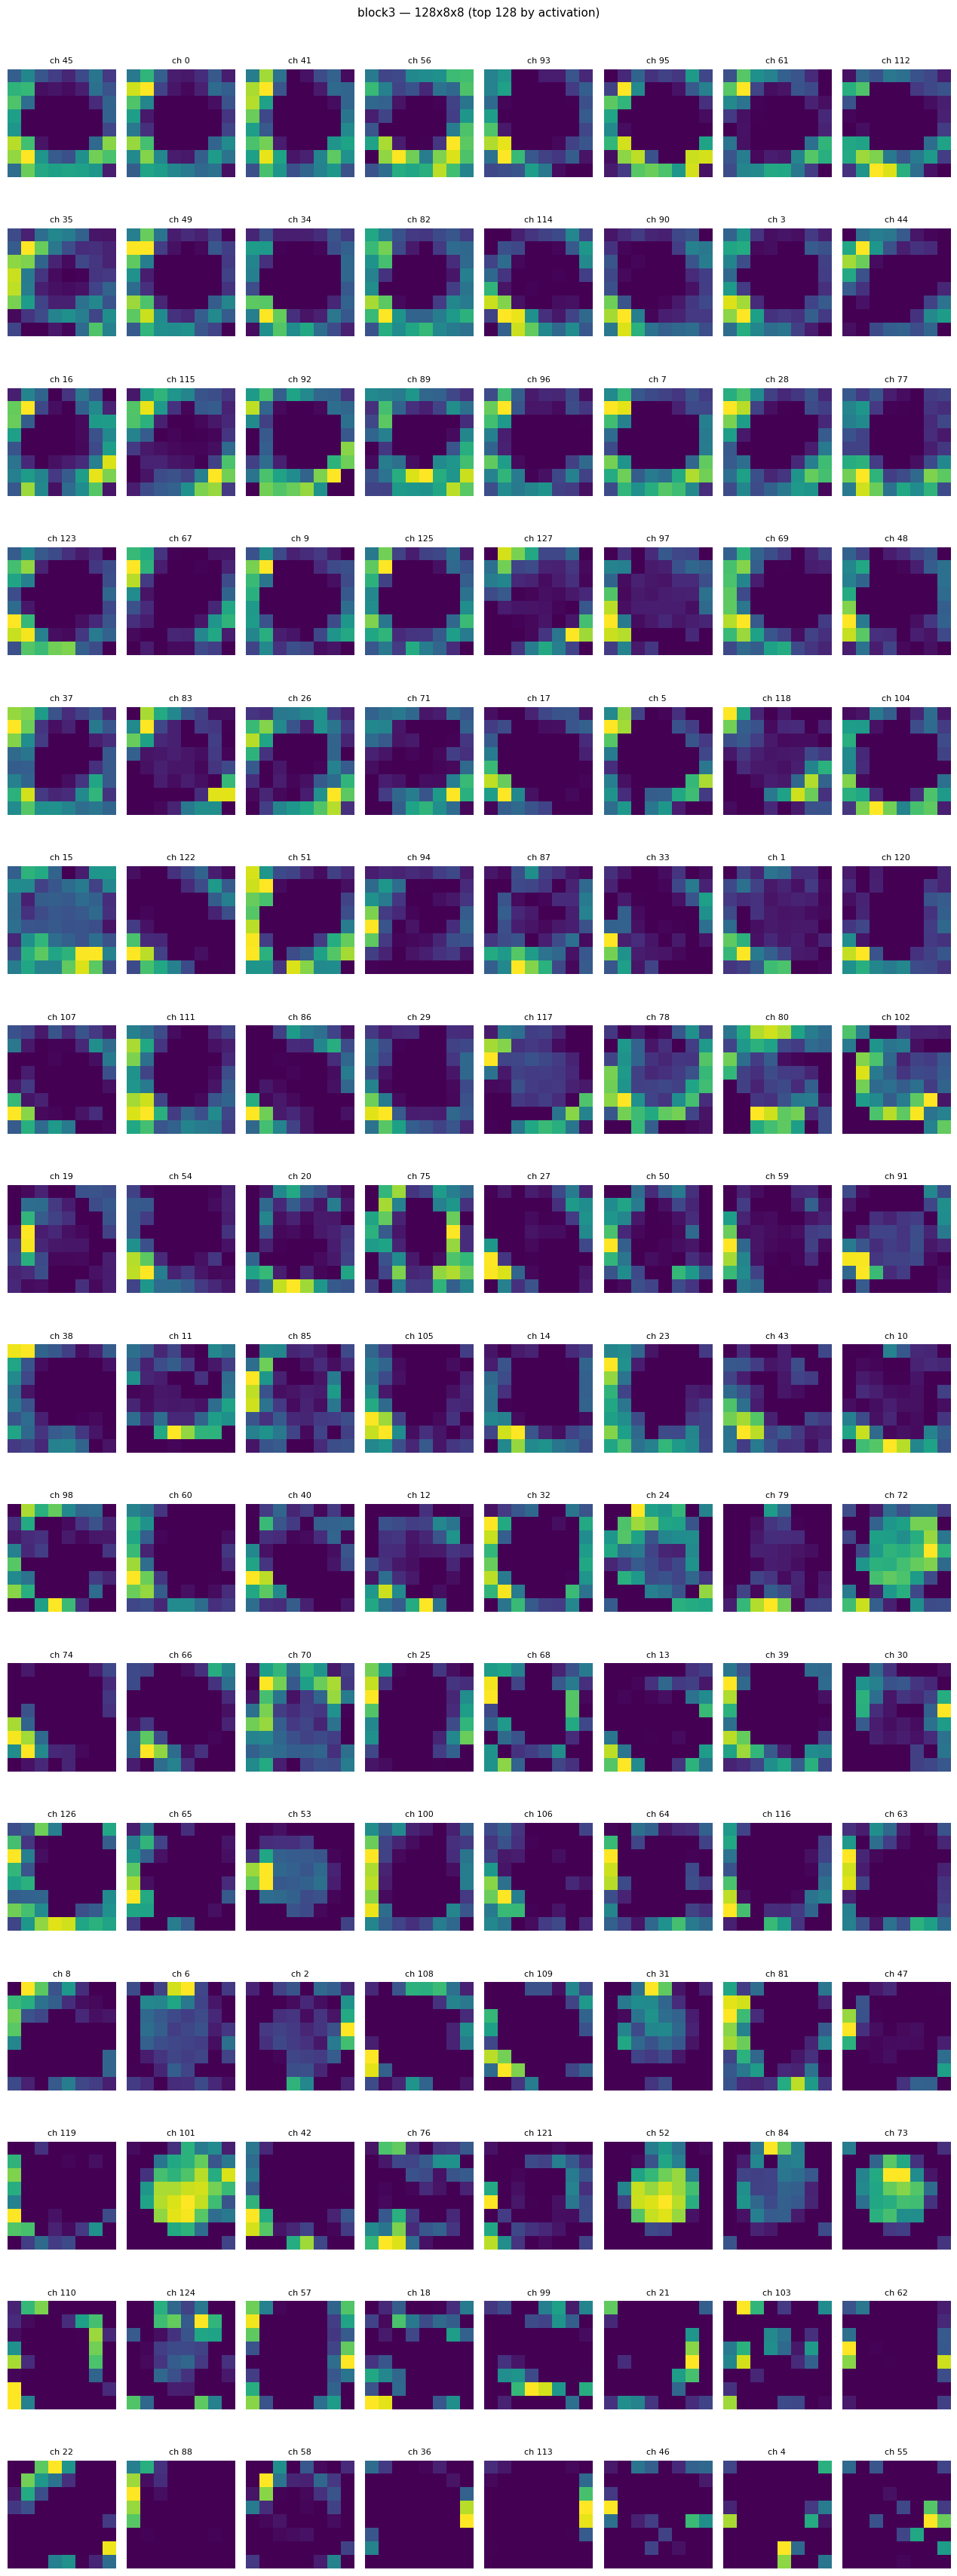

In [272]:
plot_feature_maps(maps, "block3", max_channels=128)

## Hybrid CNN

In this section, we will build a hybrid model that combines the trained CNN encoder and engineered features

### Engineered Features

In [37]:
from scipy import ndimage
from scipy.ndimage import binary_erosion
from skimage.measure import label, regionprops
from skimage.transform import probabilistic_hough_line

In [31]:
def defect_ratio(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = np.sum(valid)
    return np.sum(defects) / n_valid if n_valid > 0 else 0.0

df_labeled["defect_ratio"] = df_labeled["waferMap"].apply(defect_ratio)

print(
    df_labeled.groupby("failureType")["defect_ratio"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none         0.11
Edge-Ring    0.15
Edge-Loc     0.18
Center       0.23
Loc          0.15
Scratch      0.10
Random       0.48
Donut        0.28
Near-full    0.88
Name: defect_ratio, dtype: float64


In [32]:
def avg_distance_from_center(wm):
    valid = (wm > 0)
    defects = (wm == 2)

    # no valid wafer or no defects
    if np.sum(valid) == 0 or np.sum(defects) == 0:
        return 0.0

    # centorid of all valid die locations
    valid_coords = np.argwhere(valid)
    cy, cx = valid_coords.mean(axis=0)

    # coordinates of defect dies
    defect_coords = np.argwhere(defects)

    # distance of each defect die to wafer center
    d = np.sqrt((defect_coords[:, 0] - cy)**2 + (defect_coords[:, 1] - cx)**2)

    # max valid distance used to normalize by wafer size
    yy, xx = np.indices(wm.shape)
    all_dist = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    max_r = all_dist[valid].max()

    return d.mean() / max_r if max_r > 0 else 0.0

df_labeled["avg_distance_center"] = df_labeled["waferMap"].apply(avg_distance_from_center)

print(
    df_labeled.groupby("failureType")["avg_distance_center"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none         0.71
Edge-Ring    0.83
Edge-Loc     0.73
Center       0.60
Loc          0.67
Scratch      0.69
Random       0.65
Donut        0.57
Near-full    0.64
Name: avg_distance_center, dtype: float64


In [33]:
def largest_cluster_ratio(wm, min_cluster_size=0):
    defects = (wm == 2)
    total_defects = np.sum(defects)

    # no defect dies
    if total_defects == 0:
        return 0.0

    # label connected defect regions
    structure = np.ones((3, 3), dtype=int)
    labeled, n = ndimage.label(defects, structure=structure)

    # no clusters found
    if n == 0:
        return 0.0

    # size of each defect cluster
    cluster_sizes = ndimage.sum(defects, labeled, index=np.arange(1, n + 1))
    cluster_sizes = np.asarray(cluster_sizes)

    # keep only clusters above minimum size
    valid_clusters = cluster_sizes[cluster_sizes >= min_cluster_size]

    # no cluster meets minimum size
    if len(valid_clusters) == 0:
        return 0.0

    # largest valid cluster divided by all defects
    return np.max(valid_clusters) / total_defects

df_labeled["largest_cluster_ratio"] = df_labeled["waferMap"].apply(largest_cluster_ratio)

print(
    df_labeled.groupby("failureType")["largest_cluster_ratio"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none         0.09
Edge-Ring    0.64
Edge-Loc     0.34
Center       0.33
Loc          0.35
Scratch      0.24
Random       0.76
Donut        0.63
Near-full    1.00
Name: largest_cluster_ratio, dtype: float64


In [34]:
def num_clusters(wm, min_cluster_size=3):
    defects = (wm == 2)

    # label connected defect regions
    structure = np.ones((3, 3), dtype=int)
    labeled, n = ndimage.label(defects, structure=structure)

    # no clusters found
    if n == 0:
        return 0

    # size of each cluster
    cluster_sizes = ndimage.sum(defects, labeled, index=np.arange(1, n + 1))

    # count only clusters at or above the minimum size
    return int(np.sum(cluster_sizes >= min_cluster_size))

df_labeled["num_clusters"] = df_labeled["waferMap"].apply(num_clusters)

print(
    df_labeled.groupby("failureType")["num_clusters"]
    .mean()
    .reindex(classes)
    .round(2)
)

failureType
none          7.09
Edge-Ring     6.76
Edge-Loc     10.57
Center       11.20
Loc           8.47
Scratch       7.83
Random       10.27
Donut         9.96
Near-full     1.31
Name: num_clusters, dtype: float64


In [41]:
ef = [
    "defect_ratio",
    "avg_distance_center",
    "largest_cluster_ratio",
    "num_clusters",
]

### Geometry-based features (Wu et al. 2015)

In [38]:
def regional_attributes(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())
    out = {k: 0.0 for k in regional_cols}

    if n_valid == 0 or defects.sum() == 0:
        return pd.Series(out)

    r = np.sqrt(n_valid / np.pi)
    vy, vx = np.argwhere(valid).mean(axis=0)

    labeled = label(defects, connectivity=2)
    props = regionprops(labeled)
    if not props:
        return pd.Series(out)

    sa = max(props, key=lambda p: p.area)
    sp = max(props, key=lambda p: p.perimeter if p.perimeter > 0 else 0)

    def describe(reg):
        coords = reg.coords
        d = np.sqrt((coords[:, 0] - vy) ** 2 + (coords[:, 1] - vx) ** 2) / r
        mj, mi = reg.major_axis_length, reg.minor_axis_length
        ecc = np.sqrt(max(1.0 - (mi ** 2) / (mj ** 2), 0.0)) if mj > 0 else 0.0
        return d.max(), d.min(), mj / r, mi / r, reg.solidity, ecc

    out["sa_area_ratio"]  = sa.area / (np.pi * r * r)
    out["sp_perim_ratio"] = sp.perimeter / r
    (out["sa_max_dist"], out["sa_min_dist"],
     out["sa_major_axis"], out["sa_minor_axis"],
     out["sa_solidity"], out["sa_eccentricity"]) = describe(sa)
    (out["sp_max_dist"], out["sp_min_dist"],
     out["sp_major_axis"], out["sp_minor_axis"],
     out["sp_solidity"], out["sp_eccentricity"]) = describe(sp)

    return pd.Series(out)

regional_cols = [
    "sa_area_ratio", "sp_perim_ratio",
    "sa_max_dist", "sa_min_dist", "sa_major_axis", "sa_minor_axis",
    "sa_solidity", "sa_eccentricity",
    "sp_max_dist", "sp_min_dist", "sp_major_axis", "sp_minor_axis",
    "sp_solidity", "sp_eccentricity",
]

df_labeled[regional_cols] = df_labeled["waferMap"].apply(regional_attributes)

print(
    df_labeled.groupby("failureType")[regional_cols]
    .mean()
    .reindex(classes)
    .round(3)
)

/var/folders/7h/67fgn10165jgb8trlllk1y380000gn/T/ipykernel_16536/1046272760.py:24: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  mj, mi = reg.major_axis_length, reg.minor_axis_length
/var/folders/7h/67fgn10165jgb8trlllk1y380000gn/T/ipykernel_16536/1046272760.py:24: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  mj, mi = reg.major_axis_length, reg.minor_axis_length


             sa_area_ratio  sp_perim_ratio  sa_max_dist  sa_min_dist  \
failureType                                                            
none                 0.010           0.410        0.848        0.688   
Edge-Ring            0.096           7.139        1.033        0.827   
Edge-Loc             0.076           2.574        1.023        0.667   
Center               0.089           2.531        0.503        0.036   
Loc                  0.058           2.009        0.837        0.379   
Scratch              0.027           1.435        0.915        0.417   
Random               0.387          16.645        1.010        0.073   
Donut                0.191           6.756        0.786        0.176   
Near-full            0.873          13.608        1.039        0.026   

             sa_major_axis  sa_minor_axis  sa_solidity  sa_eccentricity  \
failureType                                                               
none                 0.376          0.146        0.709   

In [39]:
def statistical_attributes(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())
    if n_valid == 0:
        return pd.Series({"global_rdd": 0.0, "ring1_rdd": 0.0, "ring2_rdd": 0.0})

    struct = np.ones((3, 3), dtype=bool)
    eroded1 = binary_erosion(valid, structure=struct)
    ring1 = valid & ~eroded1
    eroded2 = binary_erosion(eroded1, structure=struct)
    ring2 = eroded1 & ~eroded2

    n_ring1, n_ring2 = int(ring1.sum()), int(ring2.sum())

    return pd.Series({
        "global_rdd": defects.sum() / n_valid,
        "ring1_rdd": (defects & ring1).sum() / n_ring1 if n_ring1 > 0 else 0.0,
        "ring2_rdd": (defects & ring2).sum() / n_ring2 if n_ring2 > 0 else 0.0,
    })

stat_cols = ["global_rdd", "ring1_rdd", "ring2_rdd"]
df_labeled[stat_cols] = df_labeled["waferMap"].apply(statistical_attributes)

print(
    df_labeled.groupby("failureType")[stat_cols]
    .mean()
    .reindex(classes)
    .round(3)
)

             global_rdd  ring1_rdd  ring2_rdd
failureType                                  
none              0.106      0.218      0.098
Edge-Ring         0.151      0.828      0.174
Edge-Loc          0.183      0.387      0.230
Center            0.232      0.336      0.159
Loc               0.150      0.230      0.125
Scratch           0.101      0.206      0.102
Random            0.481      0.594      0.470
Donut             0.277      0.272      0.124
Near-full         0.877      0.861      0.838


In [40]:
def hough_line_count(wm):
    valid = (wm > 0)
    defects = (wm == 2)
    n_valid = int(valid.sum())
    if n_valid == 0 or defects.sum() == 0:
        return 0

    diameter = 2.0 * np.sqrt(n_valid / np.pi)
    lines = probabilistic_hough_line(
        defects.astype(np.uint8),
        threshold=10,
        line_length=max(int(0.10 * diameter), 1),
        line_gap=max(int(0.03 * diameter), 1),
    )
    return len(lines)

df_labeled["num_lines"] = df_labeled["waferMap"].apply(hough_line_count)

print(
    df_labeled.groupby("failureType")["num_lines"]
    .mean()
    .reindex(classes)
    .round(3)
)

failureType
none          1.125
Edge-Ring    13.785
Edge-Loc      9.187
Center       10.166
Loc           6.846
Scratch       3.598
Random       51.961
Donut        26.550
Near-full    46.691
Name: num_lines, dtype: float64


In [82]:
pf = regional_cols + stat_cols + ["num_lines"]

In [83]:
# feature_cols = ef # Use our engineered features

feature_cols = pf # Use only paper features

# feature_cols = ef + pf

feature_cols

['sa_area_ratio',
 'sp_perim_ratio',
 'sa_max_dist',
 'sa_min_dist',
 'sa_major_axis',
 'sa_minor_axis',
 'sa_solidity',
 'sa_eccentricity',
 'sp_max_dist',
 'sp_min_dist',
 'sp_major_axis',
 'sp_minor_axis',
 'sp_solidity',
 'sp_eccentricity',
 'global_rdd',
 'ring1_rdd',
 'ring2_rdd',
 'num_lines']

Dataloaders

In [62]:
df_train_val, df_test = train_test_split(
    df_labeled,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=df_labeled["failureType"]
)
df_train_final, df_val = train_test_split(
    df_train_val,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=df_train_val["failureType"]
)

In [63]:
df_train_balanced = balance_df(
    df_train_final, 
    oversample=OVERSAMPLE, 
    oversample_target=OVERSAMPLE_TARGET, 
    undersample=UNDERSAMPLE, 
    undersample_target=UNDERSAMPLE_TARGET
)

In [64]:
train_loader_ordered = DataLoader(WaferDataset(
        df_train_balanced, strategy=STRATEGY, augment=False
    ),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

val_loader = DataLoader(WaferDataset(
        df_val, strategy=STRATEGY
    ), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

test_loader = DataLoader(WaferDataset(
        df_test, strategy=STRATEGY
    ), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

Create embeddings

In [80]:
# Uncomment if loading saved weights

# model_path = "checkpoints/best/resnet.pt" # change to where the weights are saved
# resnet = ResNet18().to(device)

# if os.path.exists(model_path):
#     ckpt = torch.load(model_path, map_location=device, weights_only=False)
#     resnet.load_state_dict(ckpt["model_state_dict"])
#     results["resnet"] = ckpt["results"]
#     print(f"Loaded {model_path}")
# else:
#     print(f"No checkpoint at {model_path}")

Loaded checkpoints/best/cnn_large.pt


In [66]:
def get_embeddings(model, x):
    x = model.features(x)
    x = x.flatten(1)
    x = torch.relu(model.fc(x))
    return x

def extract_embeddings_from_loader(model, loader):
    all_emb, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Extracting"):
            x = x.to(device)
            emb = get_embeddings(model, x)
            all_emb.append(emb.cpu())
            all_labels.append(y)
    return torch.cat(all_emb).numpy(), torch.cat(all_labels).numpy()

In [67]:
emb_train, y_train = extract_embeddings_from_loader(resnet, train_loader_ordered)
emb_val, y_val = extract_embeddings_from_loader(resnet, val_loader)
emb_test, y_test = extract_embeddings_from_loader(resnet, test_loader)

print(f"Train: {emb_train.shape}")
print(f"Val: {emb_val.shape}")
print(f"Test: {emb_test.shape}")

Extracting:   0%|          | 0/578 [00:00<?, ?it/s]

Extracting:   0%|          | 0/136 [00:00<?, ?it/s]

Extracting:   0%|          | 0/271 [00:00<?, ?it/s]

Train: (73930, 256)
Val: (17295, 256)
Test: (34590, 256)


In [84]:
ef_train = df_train_balanced[feature_cols]
ef_val = df_val[feature_cols]
ef_test = df_test[feature_cols]

print(f"Train: {ef_train.shape}")
print(f"Val: {ef_val.shape}")
print(f"Test: {ef_test.shape}")

Train: (73930, 18)
Val: (17295, 18)
Test: (34590, 18)


Concatenate both

In [90]:
X_train = np.concatenate([emb_train, ef_train], axis=1)
X_val = np.concatenate([emb_val, ef_val], axis=1)
X_test = np.concatenate([emb_test, ef_test], axis=1)

print(f"Concatenated X_train: {X_train.shape} - (256 CNN + {len(feature_cols)} engineered = {256 + len(feature_cols)})")

Concatenated X_train: (73930, 274) - (256 CNN + 18 engineered = 274)


### Training

In [70]:
from sklearn.ensemble import RandomForestClassifier
from torch.utils.data import TensorDataset

#### Random Forest

In [71]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)
rf.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


Evaluation

In [72]:
y_pred_test_rf = rf.predict(X_test)

report_rf = classification_report(y_test, y_pred_test_rf, target_names=classes, output_dict=True, zero_division=0)

results["rf"] = {
    "test": {
        "accuracy": round(report_rf["accuracy"], 4),
        "macro_f1": round(report_rf["macro avg"]["f1-score"], 4),
        "macro_precision": round(report_rf["macro avg"]["precision"], 4),
        "macro_recall": round(report_rf["macro avg"]["recall"], 4),
        "preds": y_pred_test_rf,
        "labels": y_test,
        **{f"f1_{cls}": round(report_rf[cls]["f1-score"], 4) for cls in classes},
    }
}

print(f"\n--- Hybrid CNN + Random Forest ---")
print(f"{'Class':<12} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 46)
for cls in classes:
    print(f"{cls:<12} {report_rf[cls]['f1-score']:>10.4f} {report_rf[cls]['precision']:>10.4f} {report_rf[cls]['recall']:>10.4f}")
print("-" * 46)
print(f"{'macro avg':<12} {report_rf['macro avg']['f1-score']:>10.4f} {report_rf['macro avg']['precision']:>10.4f} {report_rf['macro avg']['recall']:>10.4f}")
print(f"\nOverall Accuracy: {report_rf['accuracy']:.4f}")


--- Hybrid CNN + Random Forest ---
Class                F1  Precision     Recall
----------------------------------------------
none             0.9920     0.9916     0.9924
Edge-Ring        0.9854     0.9801     0.9907
Edge-Loc         0.8713     0.8717     0.8709
Center           0.9426     0.9388     0.9464
Loc              0.8126     0.8565     0.7730
Scratch          0.8353     0.8031     0.8703
Random           0.9159     0.9186     0.9133
Donut            0.8597     0.8636     0.8559
Near-full        0.9492     0.9655     0.9333
----------------------------------------------
macro avg        0.9071     0.9099     0.9051

Overall Accuracy: 0.9813


#### Neural Network

In [73]:
class HybridMLP(nn.Module):
    def __init__(self, in_dim=260, num_classes=9, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes),
        )
    
    def forward(self, x):
        return self.net(x)

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_s), torch.from_numpy(y_train).long())
val_ds = TensorDataset(torch.from_numpy(X_val_s),   torch.from_numpy(y_val).long())
test_ds = TensorDataset(torch.from_numpy(X_test_s),  torch.from_numpy(y_test).long())

mlp_train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
mlp_val_loader = DataLoader(val_ds,   batch_size=256, shuffle=False)
mlp_test_loader = DataLoader(test_ds,  batch_size=256, shuffle=False)

In [75]:
mlp_hybrid = HybridMLP(in_dim=X_train.shape[1], num_classes=len(classes)).to(device)

MLP_LR = 1e-4
MLP_WD = 1e-2
MLP_EPOCHS = 50
MLP_PATIENCE = 10
MLP_LABEL_SMOOTHING = 0.1

criterion_mlp = nn.CrossEntropyLoss(label_smoothing=MLP_LABEL_SMOOTHING)
optimizer_mlp = torch.optim.AdamW(mlp_hybrid.parameters(), lr=MLP_LR, weight_decay=MLP_WD)

In [76]:
best_f1 = -1.0
best_weights = None
patience_counter = 0
mlp_train_losses, mlp_val_losses, mlp_val_f1s = [], [], []

for epoch in tqdm(range(MLP_EPOCHS), desc="MLP Epochs"):
    mlp_hybrid.train()
    running_loss = 0
    for x, y in mlp_train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_mlp.zero_grad(set_to_none=True)
        loss = criterion_mlp(mlp_hybrid(x), y)
        loss.backward()
        optimizer_mlp.step()
        running_loss += loss.item()
    train_loss = running_loss / len(mlp_train_loader)
    
    mlp_hybrid.eval()
    running_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in mlp_val_loader:
            x, y = x.to(device), y.to(device)
            logits = mlp_hybrid(x)
            running_loss += criterion_mlp(logits, y).item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    val_loss = running_loss / len(mlp_val_loader)
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    
    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    mlp_val_f1s.append(val_f1)
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_weights = {k: v.clone() for k, v in mlp_hybrid.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
    
    tqdm.write(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Val F1: {val_f1:.4f} | Patience: {patience_counter}/{MLP_PATIENCE}")
    
    if patience_counter >= MLP_PATIENCE:
        tqdm.write(f"Early stopping at epoch {epoch+1}")
        break

mlp_hybrid.load_state_dict(best_weights)
print(f"Best val F1: {best_f1:.4f}")

MLP Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 01 | Train: 1.3146 | Val: 0.8344 | Val F1: 0.8230 | Patience: 0/10
Epoch 02 | Train: 0.7793 | Val: 0.6004 | Val F1: 0.8587 | Patience: 0/10
Epoch 03 | Train: 0.6498 | Val: 0.5539 | Val F1: 0.8765 | Patience: 0/10
Epoch 04 | Train: 0.6072 | Val: 0.5425 | Val F1: 0.8837 | Patience: 0/10
Epoch 05 | Train: 0.5904 | Val: 0.5356 | Val F1: 0.8844 | Patience: 0/10
Epoch 06 | Train: 0.5817 | Val: 0.5336 | Val F1: 0.8881 | Patience: 0/10
Epoch 07 | Train: 0.5752 | Val: 0.5330 | Val F1: 0.8886 | Patience: 0/10
Epoch 08 | Train: 0.5709 | Val: 0.5318 | Val F1: 0.8971 | Patience: 0/10
Epoch 09 | Train: 0.5687 | Val: 0.5319 | Val F1: 0.8983 | Patience: 0/10
Epoch 10 | Train: 0.5656 | Val: 0.5304 | Val F1: 0.9002 | Patience: 0/10
Epoch 11 | Train: 0.5637 | Val: 0.5316 | Val F1: 0.8984 | Patience: 1/10
Epoch 12 | Train: 0.5615 | Val: 0.5309 | Val F1: 0.8971 | Patience: 2/10
Epoch 13 | Train: 0.5590 | Val: 0.5308 | Val F1: 0.8998 | Patience: 3/10
Epoch 14 | Train: 0.5575 | Val: 0.5299 | Val F1: 0.

Evaluation

In [77]:
mlp_hybrid.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in mlp_test_loader:
        x, y = x.to(device), y.to(device)
        logits = mlp_hybrid(x)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

y_pred_test_mlp = np.array(all_preds)
report_mlp = classification_report(y_test, y_pred_test_mlp, target_names=classes, output_dict=True, zero_division=0)

results["hybrid_mlp"] = {
    "test": {
        "accuracy": round(report_mlp["accuracy"], 4),
        "macro_f1": round(report_mlp["macro avg"]["f1-score"], 4),
        "macro_precision": round(report_mlp["macro avg"]["precision"], 4),
        "macro_recall": round(report_mlp["macro avg"]["recall"], 4),
        "preds": y_pred_test_mlp,
        "labels": y_test,
        **{f"f1_{cls}": round(report_mlp[cls]["f1-score"], 4) for cls in classes},
    }
}

print(f"\n--- Hybrid CNN + MLP ---")
print(f"{'Class':<12} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-" * 46)
for cls in classes:
    print(f"{cls:<12} {report_mlp[cls]['f1-score']:>10.4f} {report_mlp[cls]['precision']:>10.4f} {report_mlp[cls]['recall']:>10.4f}")
print("-" * 46)
print(f"{'macro avg':<12} {report_mlp['macro avg']['f1-score']:>10.4f} {report_mlp['macro avg']['precision']:>10.4f} {report_mlp['macro avg']['recall']:>10.4f}")
print(f"\nOverall Accuracy: {report_mlp['accuracy']:.4f}")


--- Hybrid CNN + MLP ---
Class                F1  Precision     Recall
----------------------------------------------
none             0.9917     0.9934     0.9900
Edge-Ring        0.9836     0.9785     0.9886
Edge-Loc         0.8658     0.8553     0.8767
Center           0.9428     0.9358     0.9499
Loc              0.8126     0.8160     0.8092
Scratch          0.8187     0.7664     0.8787
Random           0.9143     0.9040     0.9249
Donut            0.8870     0.8571     0.9189
Near-full        0.9355     0.9062     0.9667
----------------------------------------------
macro avg        0.9058     0.8903     0.9226

Overall Accuracy: 0.9804


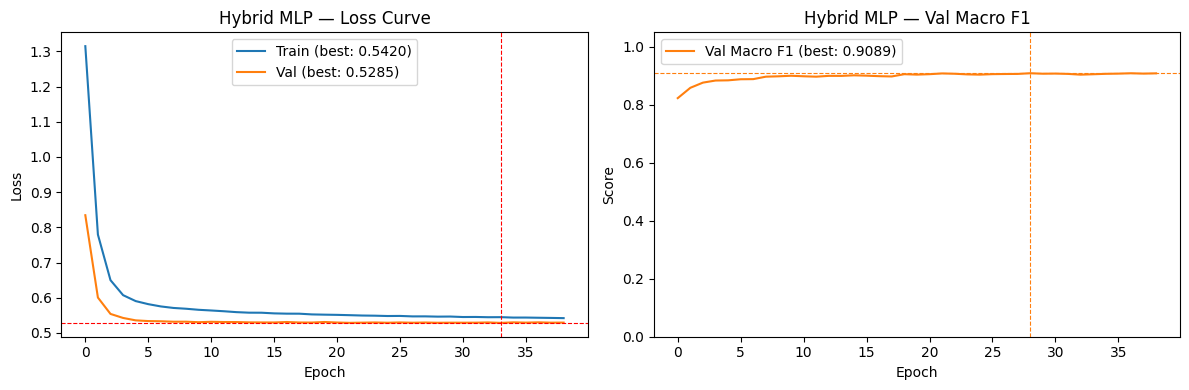

In [78]:
def plot_mlp_metrics(train_losses, val_losses, val_f1s, title="Hybrid MLP"):
    best_val_loss = min(val_losses)
    best_val_loss_epoch = val_losses.index(best_val_loss)
    best_train = min(train_losses)
    best_f1 = max(val_f1s)
    best_f1_epoch = val_f1s.index(best_f1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curve
    ax1.plot(train_losses, label=f"Train (best: {best_train:.4f})")
    ax1.plot(val_losses, label=f"Val (best: {best_val_loss:.4f})")
    ax1.axhline(best_val_loss, color="red", linestyle="--", linewidth=0.8)
    ax1.axvline(best_val_loss_epoch, color="red", linestyle="--", linewidth=0.8)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss Curve")
    ax1.legend()
    
    # F1 curve
    ax2.plot(val_f1s, label=f"Val Macro F1 (best: {best_f1:.4f})", color="C1")
    ax2.axhline(best_f1, color="C1", linestyle="--", linewidth=0.8)
    ax2.axvline(best_f1_epoch, color="C1", linestyle="--", linewidth=0.8)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1.05)
    ax2.set_title(f"{title} — Val Macro F1")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_mlp_metrics(mlp_train_losses, mlp_val_losses, mlp_val_f1s)

### Hybrid CNN Eval

In [81]:
print(f"{'Model':<30} {'Macro F1':>10}")
print("-" * 42)
print(f"{'CNN alone':<30} {results['resnet']['test']['macro_f1']:>10.4f}")
print(f"{'Hybrid (CNN + RF)':<30} {results['rf']['test']['macro_f1']:>10.4f}")
print(f"{'Hybrid (CNN + MLP)':<30} {results['hybrid_mlp']['test']['macro_f1']:>10.4f}")

print(f"\n{'Class':<12} {'CNN':>8} {'RF':>8} {'MLP':>8}")
print("-" * 48)
for cls in classes:
    cnn_cls = results["resnet"]["test"][f"f1_{cls}"]
    rf_cls = results["rf"]["test"][f"f1_{cls}"]
    mlp_cls = results["hybrid_mlp"]["test"][f"f1_{cls}"]
    print(f"{cls:<12} {cnn_cls:>8.4f} {rf_cls:>8.4f} {mlp_cls:>8.4f}")

Model                            Macro F1
------------------------------------------
CNN alone                          0.9061
Hybrid (CNN + RF)                  0.9071
Hybrid (CNN + MLP)                 0.9058

Class             CNN       RF      MLP
------------------------------------------------
none           0.9918   0.9920   0.9917
Edge-Ring      0.9810   0.9854   0.9836
Edge-Loc       0.8557   0.8713   0.8658
Center         0.9476   0.9426   0.9428
Loc            0.7872   0.8126   0.8126
Scratch        0.8504   0.8353   0.8187
Random         0.9169   0.9159   0.9143
Donut          0.8889   0.8597   0.8870
Near-full      0.9355   0.9492   0.9355
